In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.stats import entropy

Mounted at /content/drive


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/eeg_qc_outputs"

npz_path = os.path.join(SAVE_DIR, "clean_eeg_windows_qc.npz")
qc_csv_path = os.path.join(SAVE_DIR, "all_window_qc.csv")
summary_csv_path = os.path.join(SAVE_DIR, "file_quality_summary.csv")

data = np.load(npz_path, allow_pickle=True)

X = data["X"]                    # shape: (n_windows, 1000, 8)
y = data["y"]
subjects = data["subjects"]
tasks = data["tasks"]
labels = data["labels"]
file_paths = data["file_paths"]
start_secs = data["start_secs"]
quality_scores = data["quality_scores"]

qc_all = pd.read_csv(qc_csv_path)
file_summary = pd.read_csv(summary_csv_path)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("tasks:", np.unique(tasks))
print("labels:", np.unique(labels))
print("subjects:", np.unique(subjects))

X shape: (2371, 1000, 8)
y shape: (2371,)
tasks: ['Arithmetic' 'Stroop']
labels: ['highlevel' 'lowlevel' 'midlevel' 'natural']
subjects: [ 1  2  3  5  6  7  8  9 10 11 12 13 14 15]


In [ ]:
mask = (
    (tasks == "Arithmetic") &
    (labels != "natural")
)

X_a = X[mask]
y_a = y[mask]
subjects_a = subjects[mask]
labels_a = labels[mask]
file_paths_a = file_paths[mask]
start_secs_a = start_secs[mask]

print("Arithmetic non-natural windows:", X_a.shape)
print(pd.Series(labels_a).value_counts())

Arithmetic non-natural windows: (879, 1000, 8)
highlevel    376
midlevel     263
lowlevel     240
Name: count, dtype: int64


In [ ]:
FS = 250

bands = {
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 35)
}

def bandpower_from_psd(f, pxx, lo, hi):
    idx = (f >= lo) & (f <= hi)
    return np.trapezoid(pxx[idx], f[idx])

def spectral_entropy_from_psd(pxx):
    p = pxx / (np.sum(pxx) + 1e-12)
    return entropy(p)

def extract_window_features(w, fs=250):
    """
    w shape: (time, channels)
    Returns global averaged EEG features for one window.
    """
    feats = {}

    # Time-domain variance
    ch_var = np.var(w, axis=0)
    feats["mean_variance"] = np.mean(ch_var)
    feats["max_variance"] = np.max(ch_var)

    # Welch PSD per channel
    band_values = {name: [] for name in bands}
    spec_entropy_values = []

    for ch in range(w.shape[1]):
        f, pxx = welch(w[:, ch], fs=fs, nperseg=512)

        for name, (lo, hi) in bands.items():
            bp = bandpower_from_psd(f, pxx, lo, hi)
            band_values[name].append(bp)

        spec_entropy_values.append(spectral_entropy_from_psd(pxx))

    for name in bands:
        vals = np.array(band_values[name])
        feats[f"{name}_power_mean"] = np.mean(vals)
        feats[f"{name}_power_logmean"] = np.log(np.mean(vals) + 1e-12)

    feats["spectral_entropy_mean"] = np.mean(spec_entropy_values)

    # Useful ratios
    theta = feats["theta_power_mean"]
    alpha = feats["alpha_power_mean"]
    beta = feats["beta_power_mean"]

    feats["theta_alpha_ratio"] = theta / (alpha + 1e-12)
    feats["theta_beta_ratio"] = theta / (beta + 1e-12)
    feats["alpha_beta_ratio"] = alpha / (beta + 1e-12)

    feats["log_theta_alpha"] = np.log(theta + 1e-12) - np.log(alpha + 1e-12)
    feats["log_theta_beta"] = np.log(theta + 1e-12) - np.log(beta + 1e-12)

    return feats

In [ ]:
rows = []

for i in range(len(X_a)):
    feats = extract_window_features(X_a[i], FS)

    row = {
        "idx": i,
        "subject": subjects_a[i],
        "label_name": labels_a[i],
        "file_path": file_paths_a[i],
        "start_sec": start_secs_a[i],
    }
    row.update(feats)
    rows.append(row)

feat_df = pd.DataFrame(rows)

print("Feature dataframe:", feat_df.shape)
display(feat_df.head())
print(feat_df["label_name"].value_counts())

Feature dataframe: (879, 21)


,idx,subject,label_name,file_path,start_sec,mean_variance,max_variance,theta_power_mean,theta_power_logmean,alpha_power_mean,...,beta_power_mean,beta_power_logmean,gamma_power_mean,gamma_power_logmean,spectral_entropy_mean,theta_alpha_ratio,theta_beta_ratio,alpha_beta_ratio,log_theta_alpha,log_theta_beta
0,0,1,highlevel,/content/eeg_data/raw_data/Arithmetic_Data/hig...,8.0,38.787745,82.602434,19.679775,2.979591,3.869266,...,6.387483,1.854340,0.899113,-0.106347,3.269432,5.086178,3.080991,0.605758,1.626527,1.125251
1,1,1,highlevel,/content/eeg_data/raw_data/Arithmetic_Data/hig...,12.0,22.334862,44.714040,9.854492,2.287927,1.250925,...,3.246623,1.177615,0.407944,-0.896625,3.252758,7.877764,3.035306,0.385300,2.064044,1.110312
2,2,1,highlevel,/content/eeg_data/raw_data/Arithmetic_Data/hig...,16.0,8.053664,12.716736,1.449762,0.371399,1.144509,...,1.605784,0.473612,0.157405,-1.848933,3.685885,1.266710,0.902837,0.712742,0.236423,-0.102213
3,3,1,highlevel,/content/eeg_data/raw_data/Arithmetic_Data/hig...,24.0,13.769491,22.613044,3.793753,1.333356,1.966343,...,2.073298,0.729141,0.184726,-1.688880,3.514130,1.929345,1.829815,0.948413,0.657180,0.604215
4,4,1,highlevel,/content/eeg_data/raw_data/Arithmetic_Data/hig...,28.0,17.590281,36.404559,2.948565,1.081319,1.330996,...,1.390819,0.329893,0.161651,-1.822316,3.437541,2.215308,2.120020,0.956987,0.795391,0.751426


label_name
highlevel    376
midlevel     263
lowlevel     240
Name: count, dtype: int64


In [ ]:
feature_cols = [
    "mean_variance",
    "theta_power_logmean",
    "alpha_power_logmean",
    "beta_power_logmean",
    "gamma_power_logmean",
    "spectral_entropy_mean",
    "theta_alpha_ratio",
    "theta_beta_ratio",
    "log_theta_alpha",
    "log_theta_beta"
]

summary = feat_df.groupby("label_name")[feature_cols].agg(["mean", "std", "median"])
display(summary)

mean_variance                     theta_power_logmean            \
                    mean       std    median                mean       std   
label_name                                                                   
highlevel       9.796818  4.983614  9.201127            0.948137  0.708369   
lowlevel        9.449384  4.438639  8.848693            0.901448  0.740840   
midlevel       10.408770  5.391259  9.829804            0.979169  0.766471   

                     alpha_power_logmean                      \
              median                mean       std    median   
label_name                                                     
highlevel   0.807560            0.525401  0.600570  0.468426   
lowlevel    0.766705            0.431086  0.575117  0.412913   
midlevel    0.826605            0.490955  0.624838  0.397410   

           beta_power_logmean  ... theta_alpha_ratio theta_beta_ratio  \
                         mean  ...            median             mean   
label_name                     ...                                      
highlevel            0.861046  ...          1.498597         1.489595   
lowlevel             0.806345  ...          1.567791         1.421714   
midlevel             0.918105  ...          1.597296         1.496280   

                               log_theta_alpha                      \
                 std    median            mean       std    median   
label_name                                                           
highlevel   1.469699  1.023274        0.422736  0.642315  0.404527   
lowlevel    1.109442  1.019381        0.470362  0.652676  0.449667   
midlevel    1.434818  0.962886        0.488214  0.606635  0.468312   

           log_theta_beta                      
                     mean       std    median  
label_name                                     
highlevel        0.087091  0.750490  0.022997  
lowlevel         0.095103  0.709981  0.019193  
midlevel         0.061064  0.805583 -0.037821  

[3 rows x 30 columns]

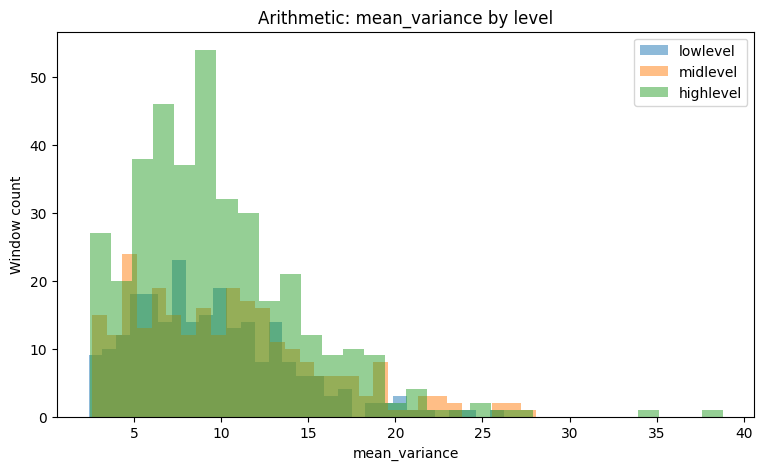

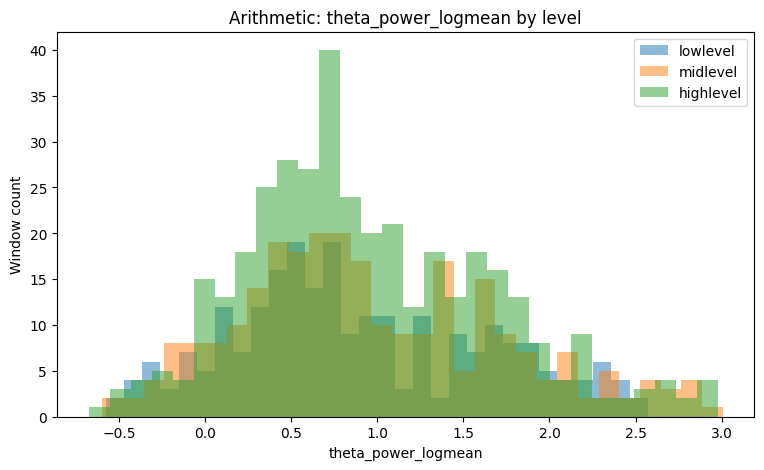

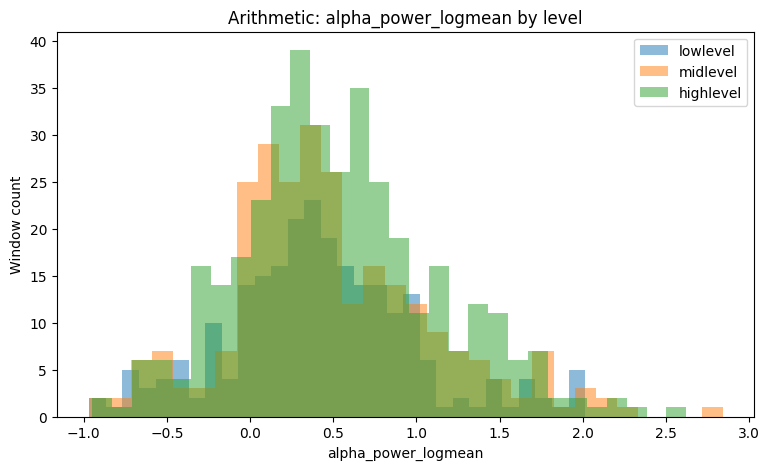

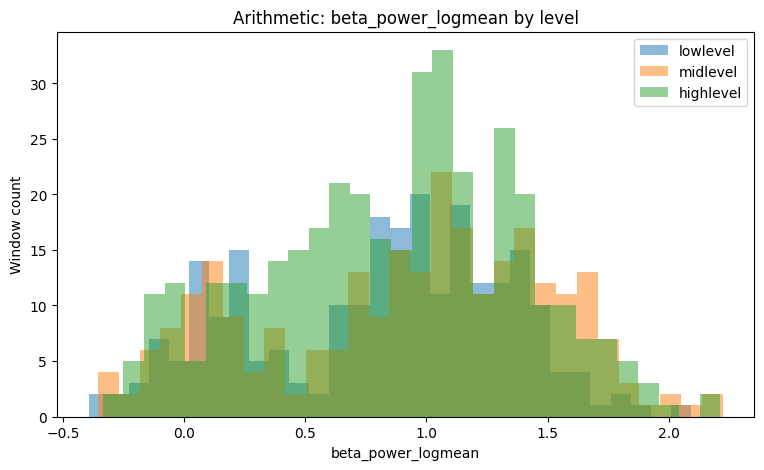

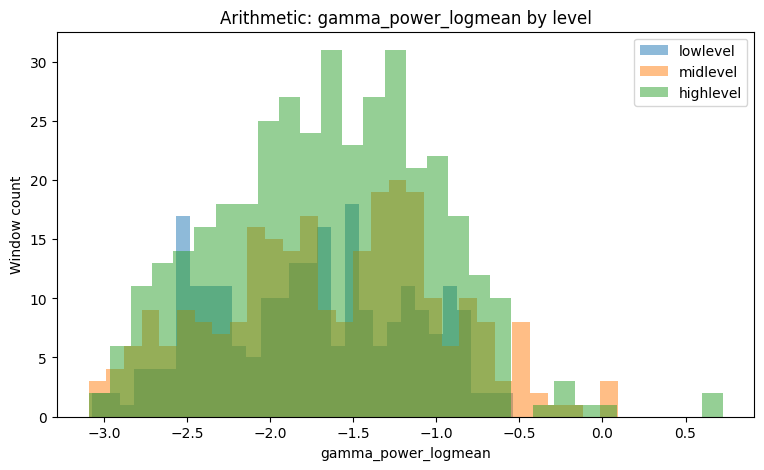

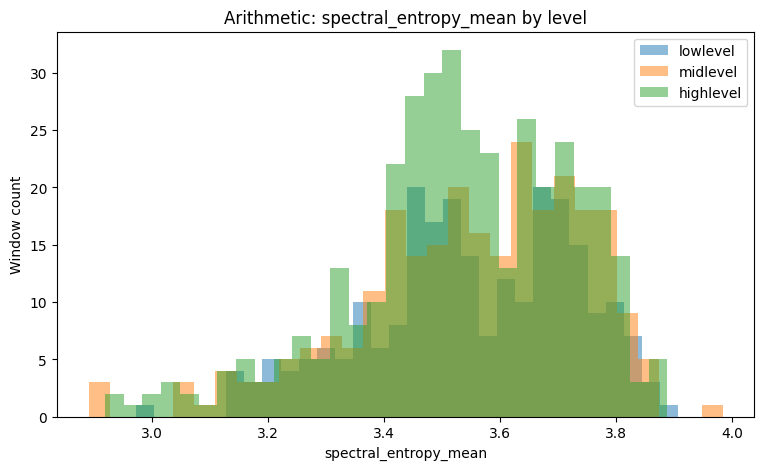

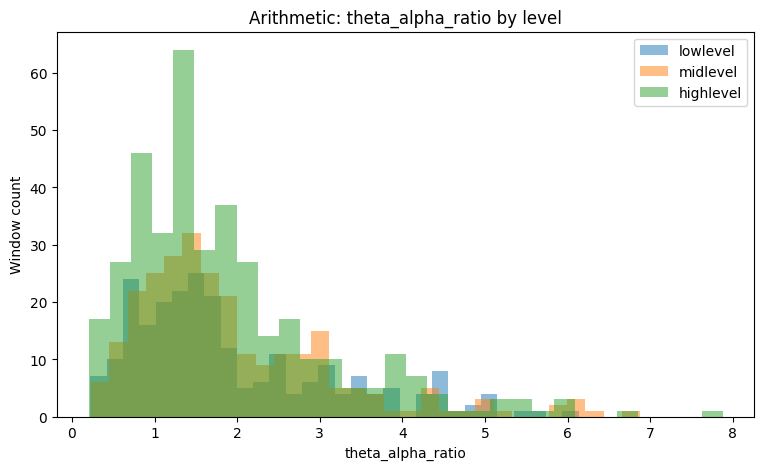

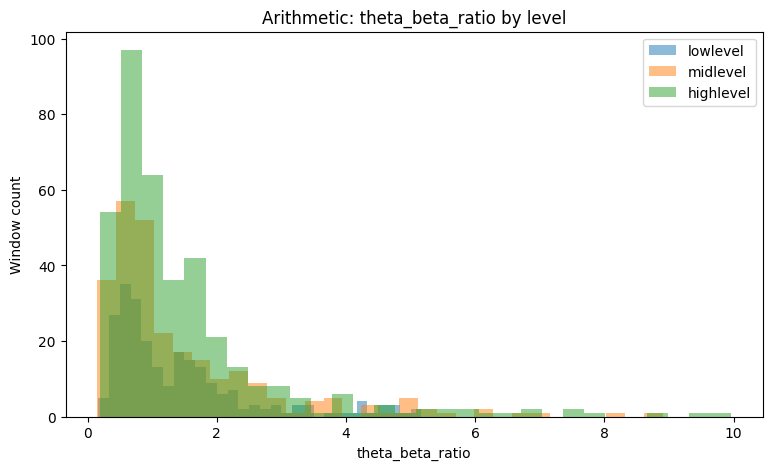

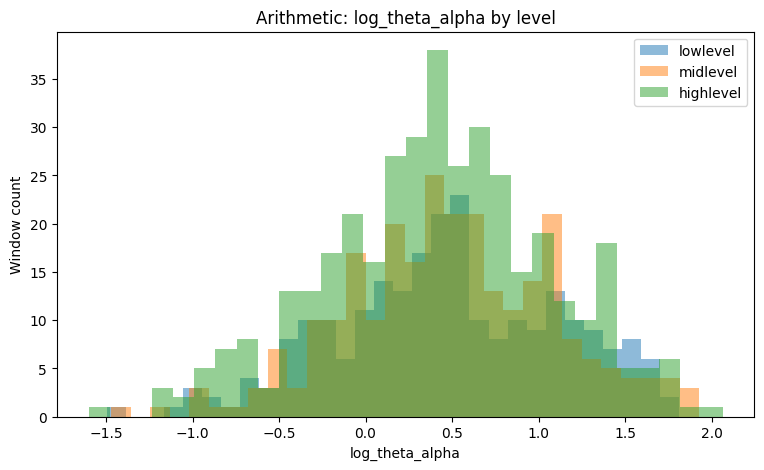

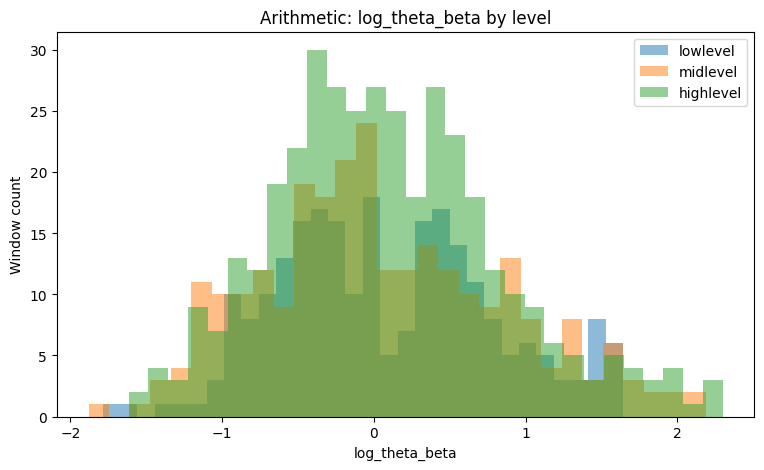

In [ ]:
def plot_feature_by_label(df, feature):
    plt.figure(figsize=(9, 5))

    for label in ["lowlevel", "midlevel", "highlevel"]:
        vals = df[df["label_name"] == label][feature].dropna()
        plt.hist(vals, bins=30, alpha=0.5, label=label)

    plt.title(f"Arithmetic: {feature} by level")
    plt.xlabel(feature)
    plt.ylabel("Window count")
    plt.legend()
    plt.show()

for feat in feature_cols:
    plot_feature_by_label(feat_df, feat)

<Figure size 800x500 with 0 Axes>

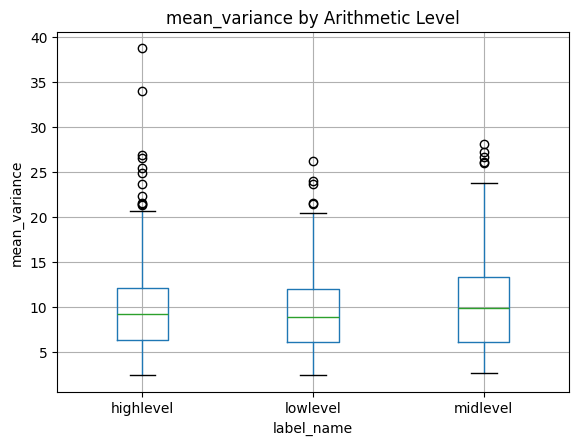

<Figure size 800x500 with 0 Axes>

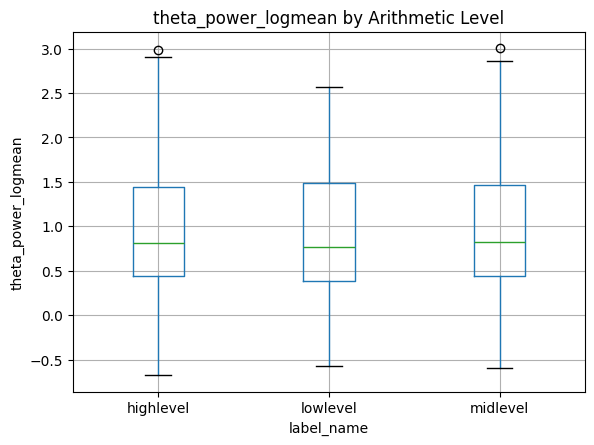

<Figure size 800x500 with 0 Axes>

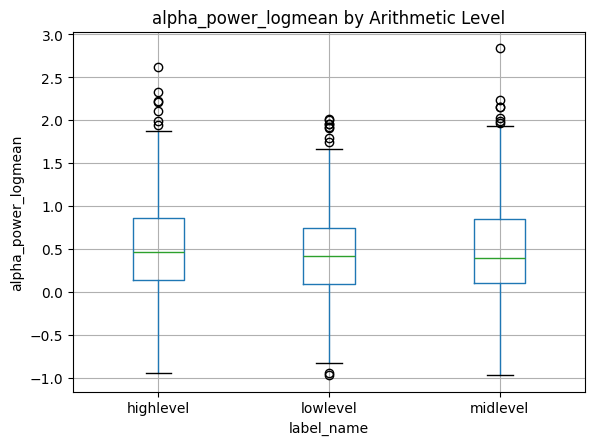

<Figure size 800x500 with 0 Axes>

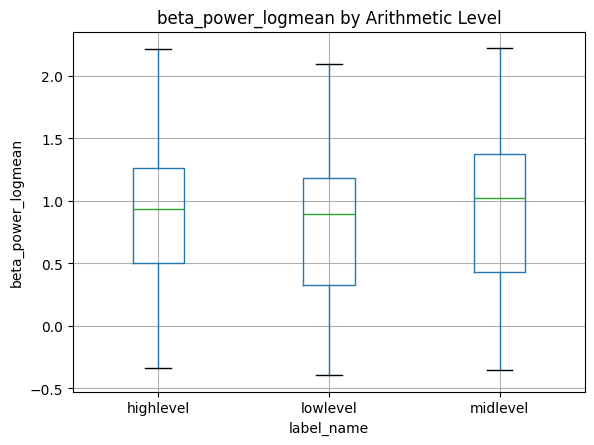

<Figure size 800x500 with 0 Axes>

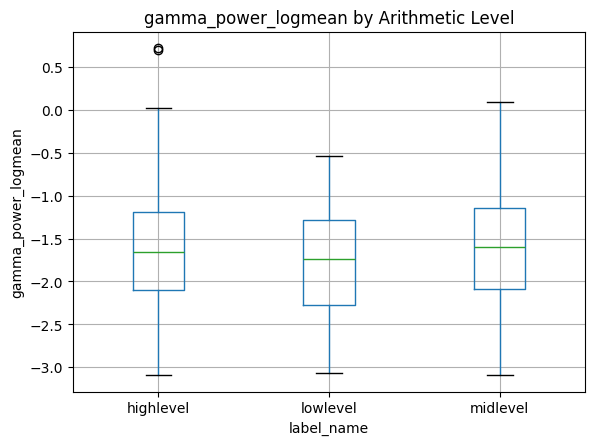

<Figure size 800x500 with 0 Axes>

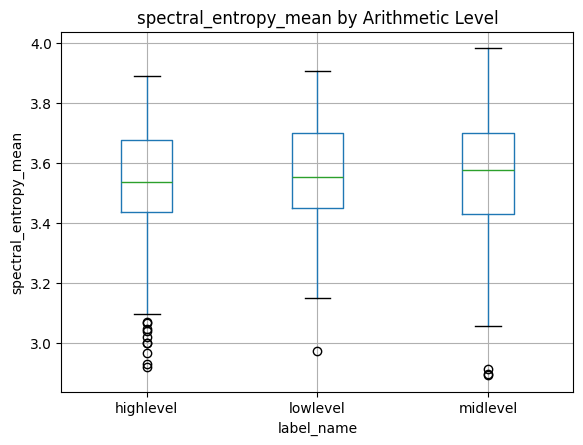

<Figure size 800x500 with 0 Axes>

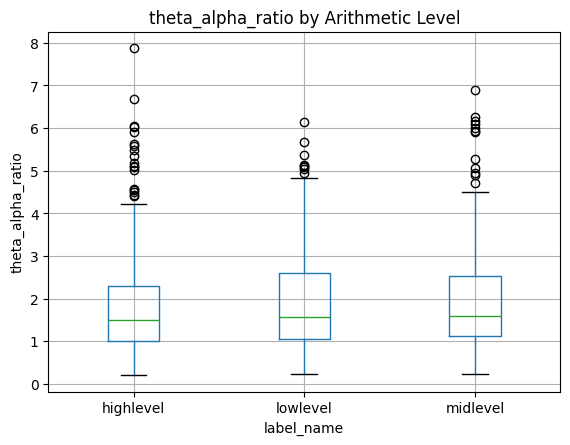

<Figure size 800x500 with 0 Axes>

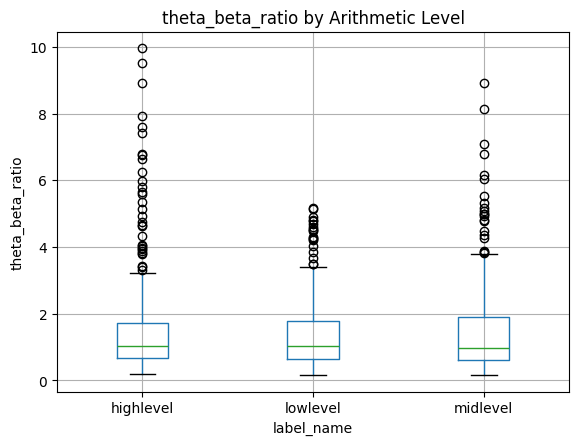

<Figure size 800x500 with 0 Axes>

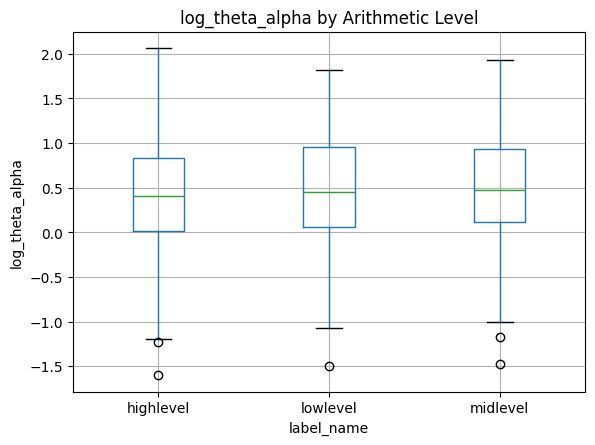

<Figure size 800x500 with 0 Axes>

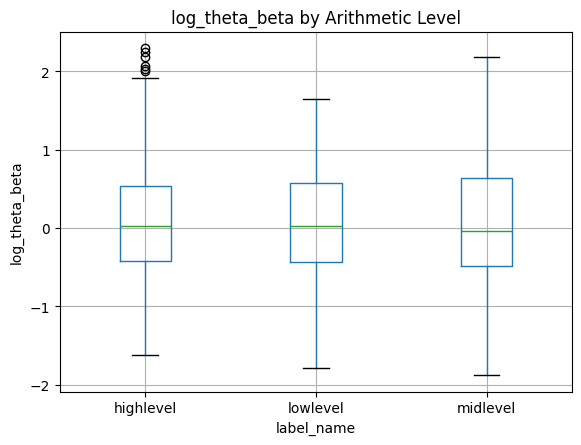

In [ ]:
for feat in feature_cols:
    plt.figure(figsize=(8, 5))
    feat_df.boxplot(column=feat, by="label_name")
    plt.title(f"{feat} by Arithmetic Level")
    plt.suptitle("")
    plt.ylabel(feat)
    plt.show()

,subject,label_name,mean_variance,theta_power_logmean,alpha_power_logmean,beta_power_logmean,gamma_power_logmean,spectral_entropy_mean,theta_alpha_ratio,theta_beta_ratio,log_theta_alpha,log_theta_beta
0,1,highlevel,18.164959,2.055710,0.747809,0.699733,-1.983275,3.223085,4.065369,4.843072,1.307901,1.355976
1,1,lowlevel,13.692346,1.739767,0.475582,0.886665,-1.580269,3.396790,3.768622,2.672468,1.264185,0.853101
2,1,midlevel,17.507607,1.926755,0.653430,0.882953,-1.588563,3.343671,3.889532,3.469503,1.273325,1.043801
3,2,highlevel,7.038569,0.479809,0.536907,0.907731,-1.324594,3.679657,1.098576,0.717942,-0.057098,-0.427922
4,2,lowlevel,6.971225,0.465173,0.643026,0.815074,-1.684676,3.604676,1.001646,0.794780,-0.177853,-0.349901


<Figure size 800x500 with 0 Axes>

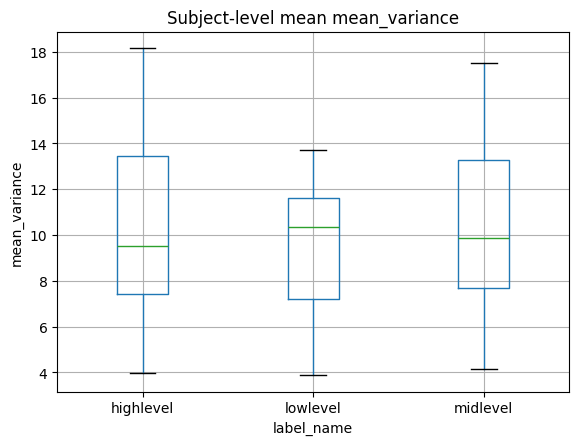

<Figure size 800x500 with 0 Axes>

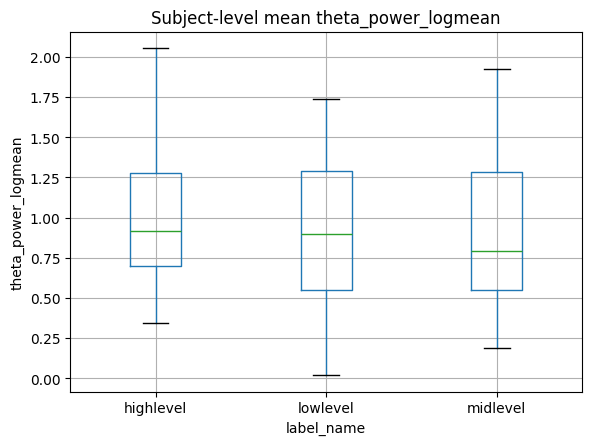

<Figure size 800x500 with 0 Axes>

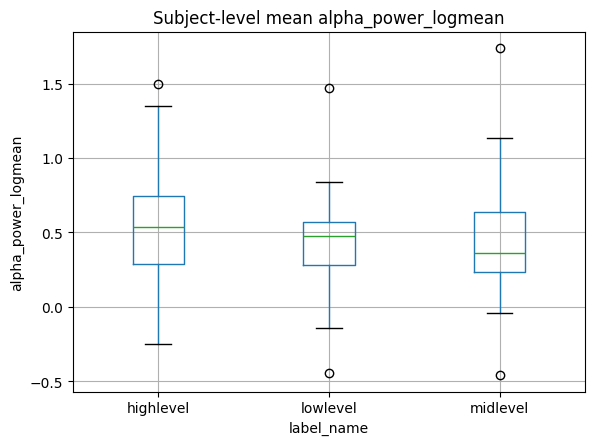

<Figure size 800x500 with 0 Axes>

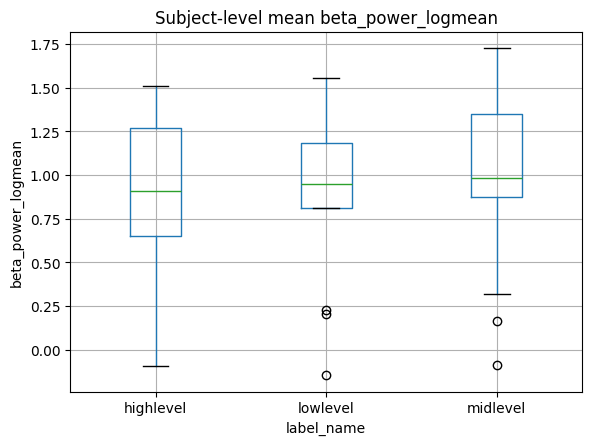

<Figure size 800x500 with 0 Axes>

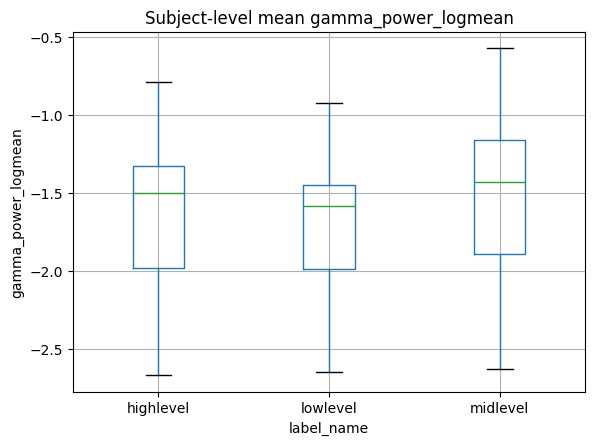

<Figure size 800x500 with 0 Axes>

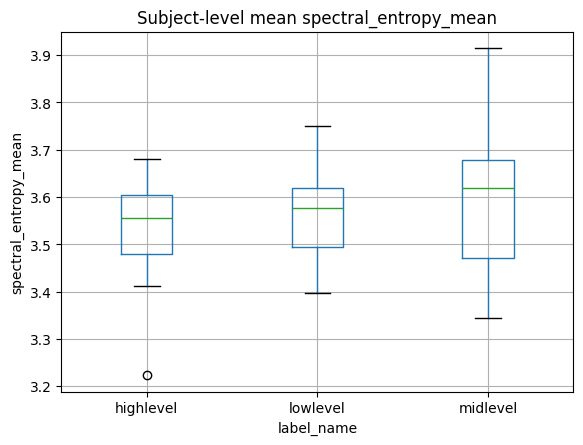

<Figure size 800x500 with 0 Axes>

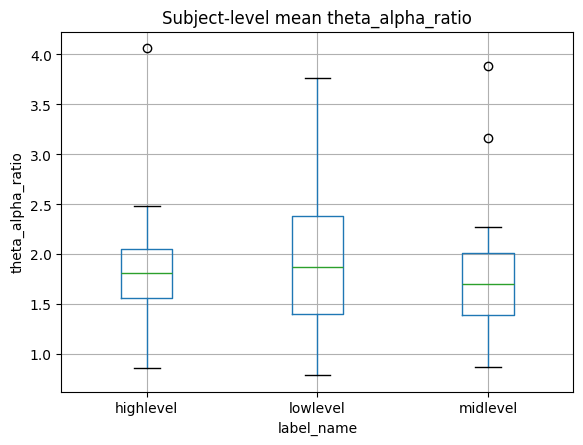

<Figure size 800x500 with 0 Axes>

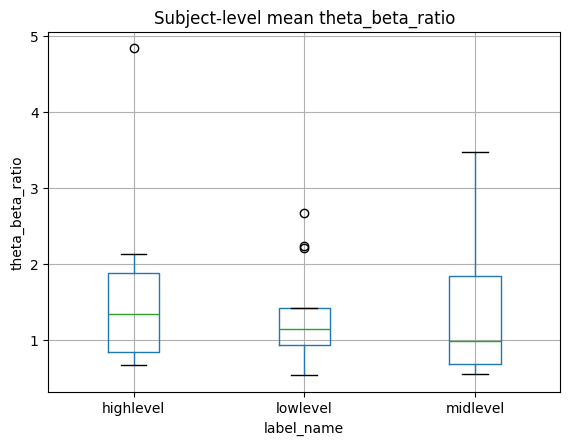

<Figure size 800x500 with 0 Axes>

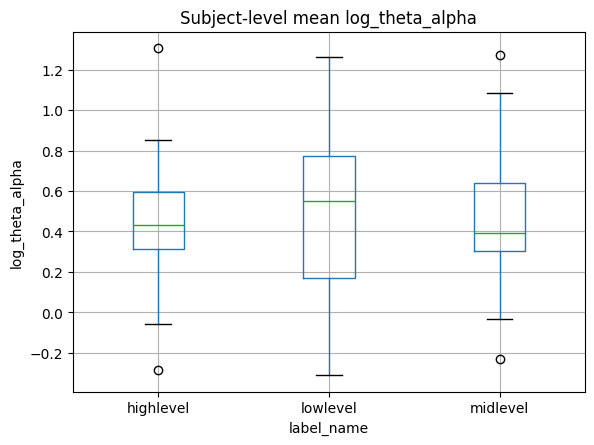

<Figure size 800x500 with 0 Axes>

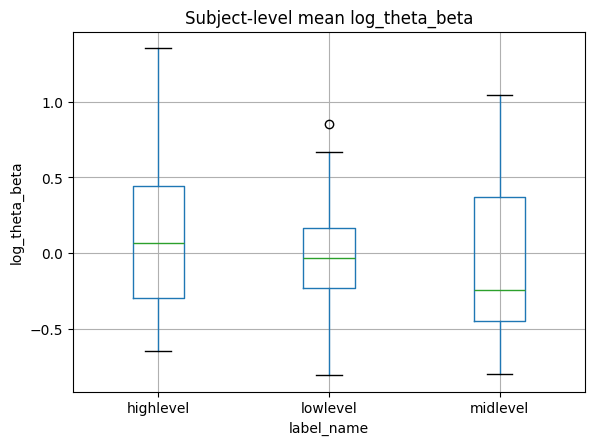

In [ ]:
subject_level = (
    feat_df
    .groupby(["subject", "label_name"])[feature_cols]
    .mean()
    .reset_index()
)

display(subject_level.head())

for feat in feature_cols:
    plt.figure(figsize=(8, 5))
    subject_level.boxplot(column=feat, by="label_name")
    plt.title(f"Subject-level mean {feat}")
    plt.suptitle("")
    plt.ylabel(feat)
    plt.show()

In [ ]:
import numpy as np

# pick a few subjects
unique_subjects = np.unique(subjects_a)
print("All subjects:", unique_subjects)

SELECT_SUBJECTS = unique_subjects[:3]  # change this if you want specific ones
print("Using subjects:", SELECT_SUBJECTS)

All subjects: [ 1  2  3  5  6  7  8  9 10 11 12 13 14 15]
Using subjects: [1 2 3]


In [ ]:
import matplotlib.pyplot as plt

def plot_subject_distributions(df, subject_id, feature_cols):
    sub_df = df[df["subject"] == subject_id]

    print(f"\n===== SUBJECT {subject_id} =====")
    print(sub_df["label_name"].value_counts())

    for feat in feature_cols:
        plt.figure(figsize=(8,4))

        for label in ["lowlevel", "midlevel", "highlevel"]:
            vals = sub_df[sub_df["label_name"] == label][feat].dropna()
            if len(vals) == 0:
                continue
            plt.hist(vals, bins=20, alpha=0.5, label=label)

        plt.title(f"Subject {subject_id}: {feat}")
        plt.xlabel(feat)
        plt.ylabel("Window count")
        plt.legend()
        plt.show()


===== SUBJECT 1 =====
label_name
highlevel    24
midlevel     22
lowlevel     21
Name: count, dtype: int64


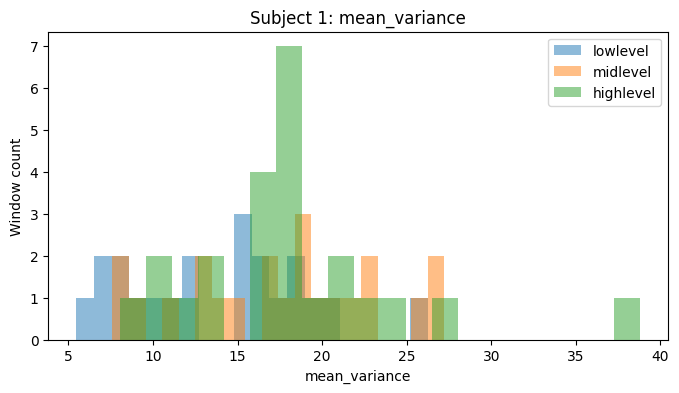

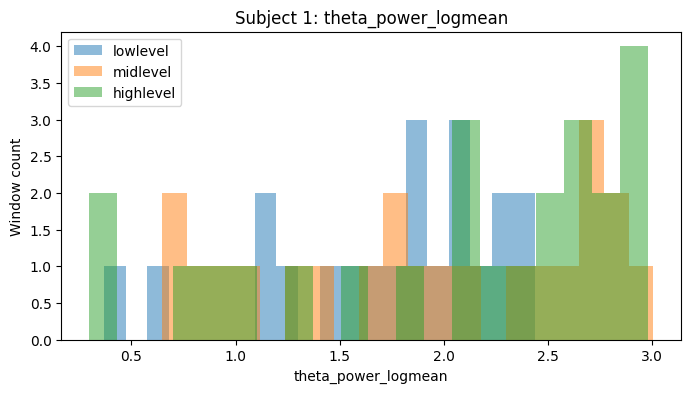

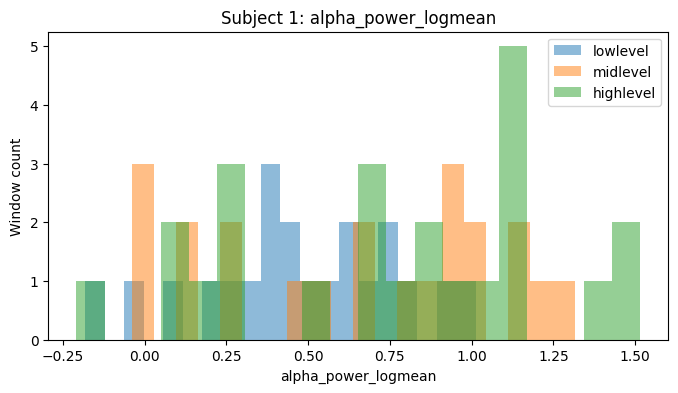

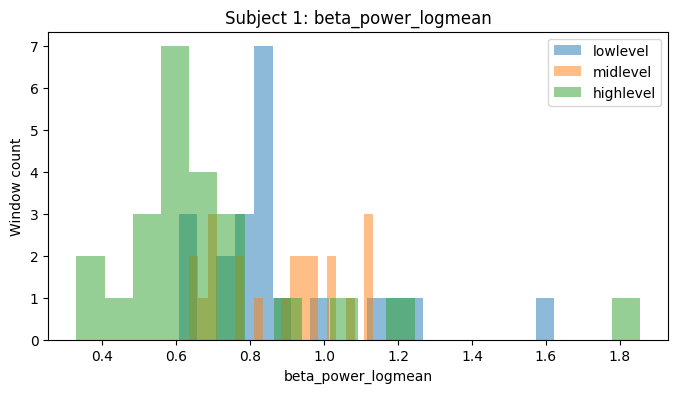

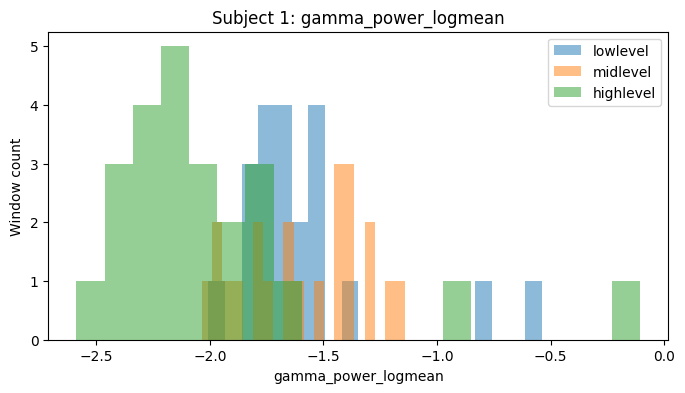

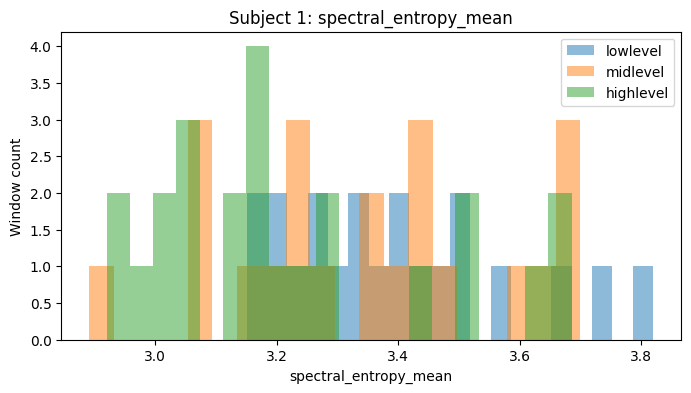

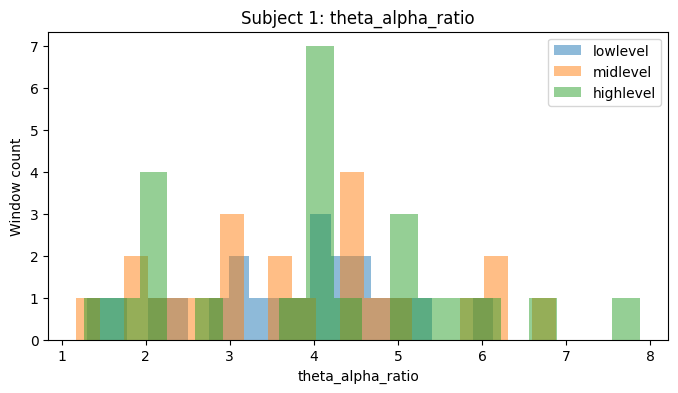

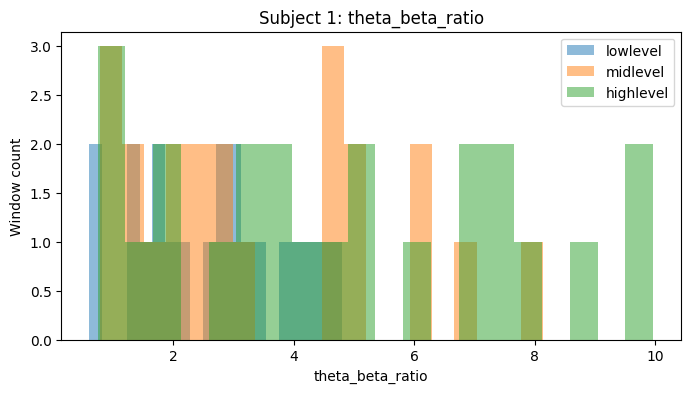

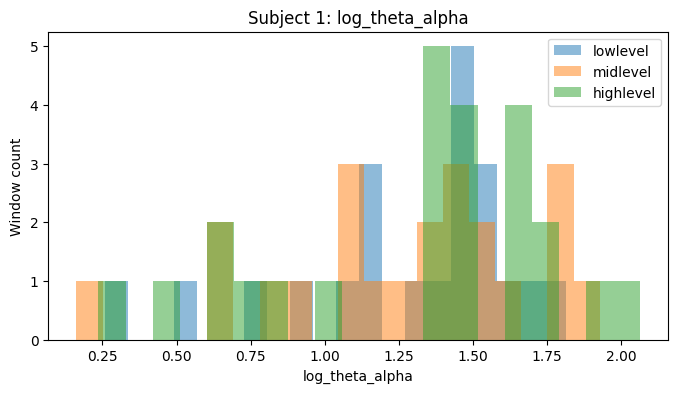

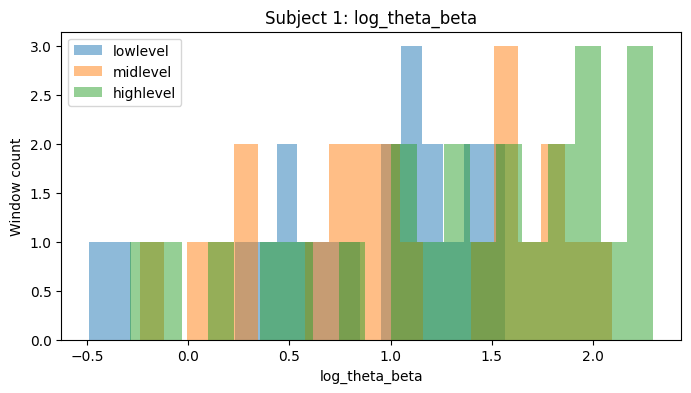


===== SUBJECT 2 =====
label_name
highlevel    34
midlevel     19
lowlevel     18
Name: count, dtype: int64


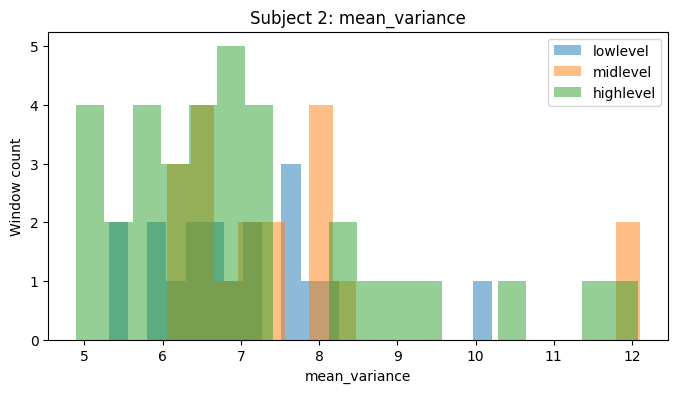

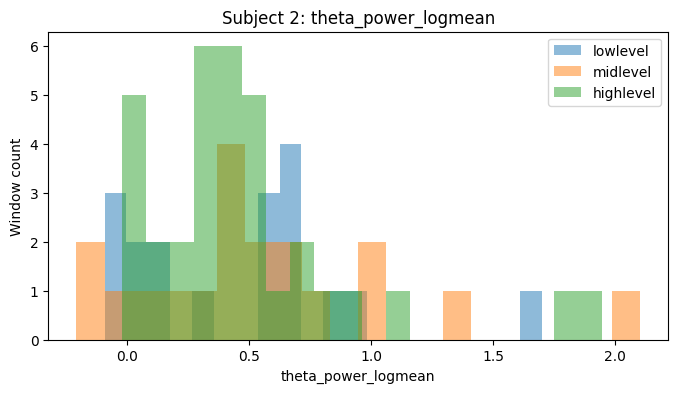

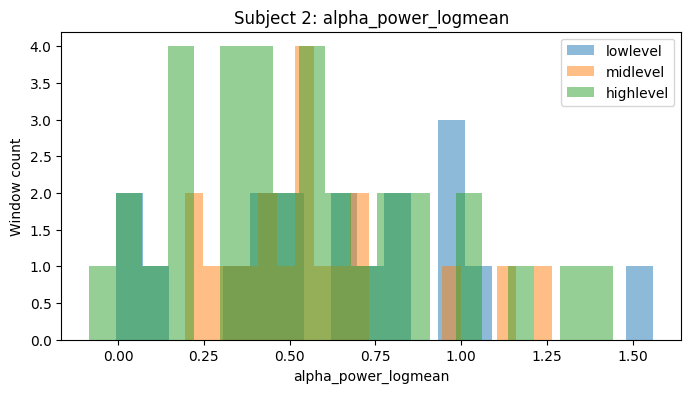

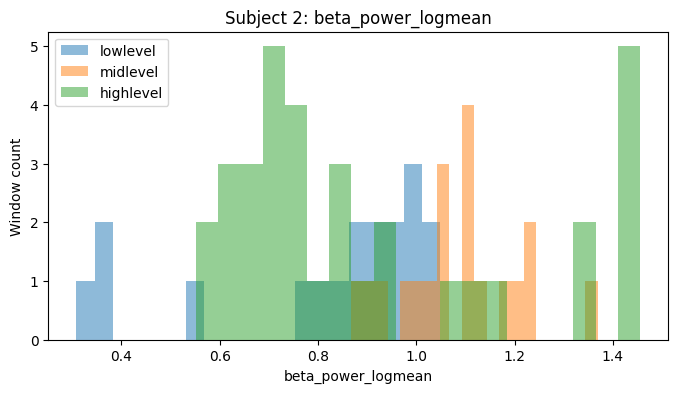

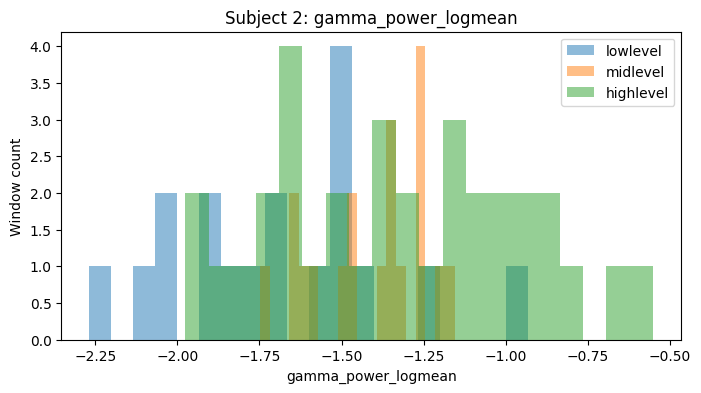

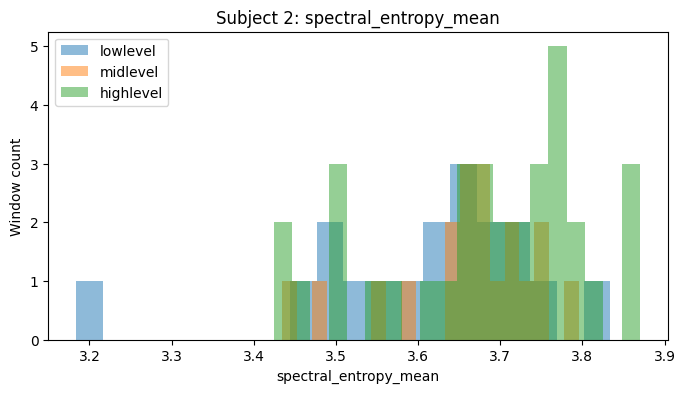

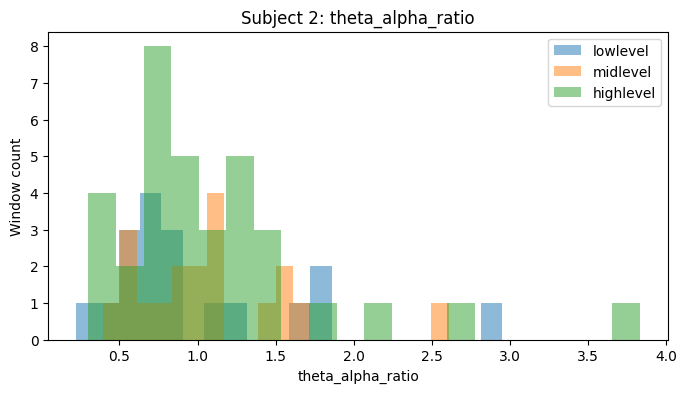

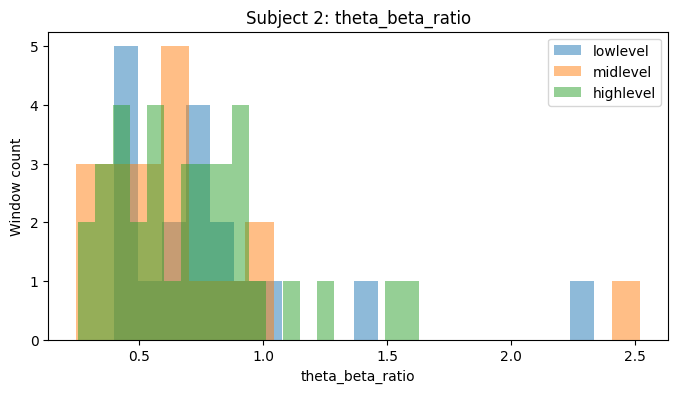

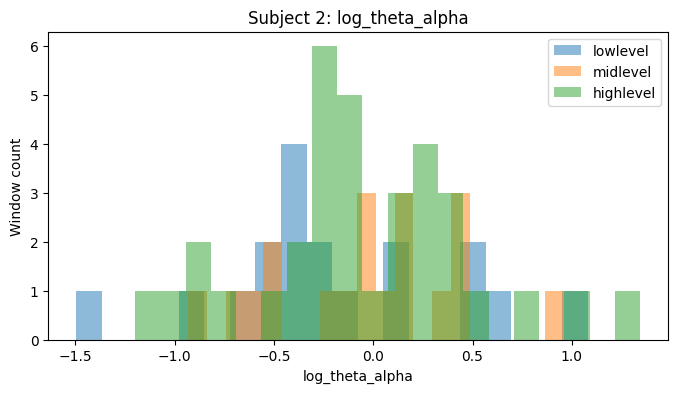

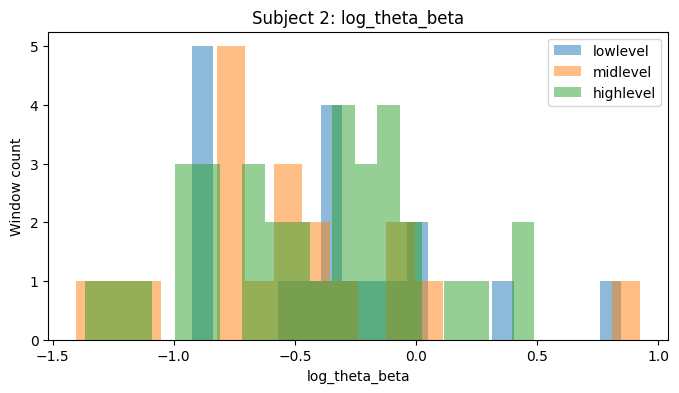


===== SUBJECT 3 =====
label_name
highlevel    22
midlevel     19
lowlevel     13
Name: count, dtype: int64


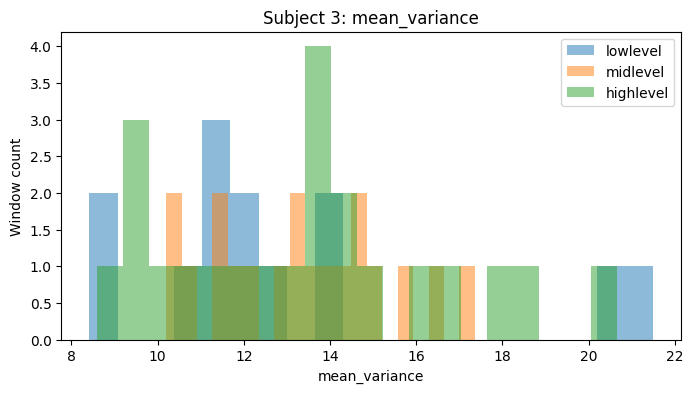

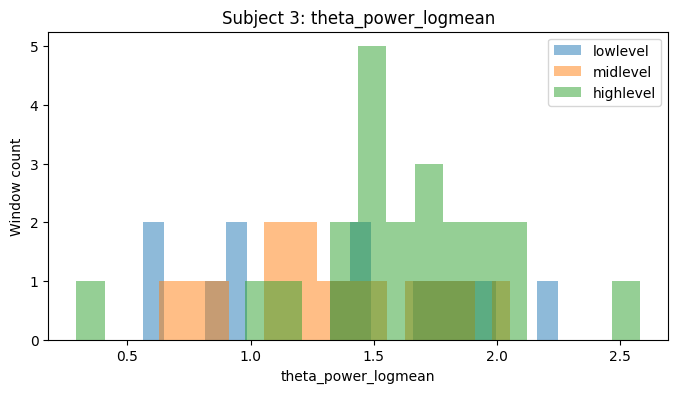

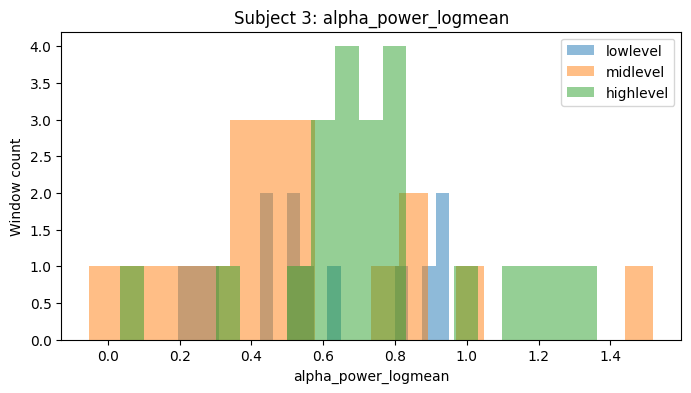

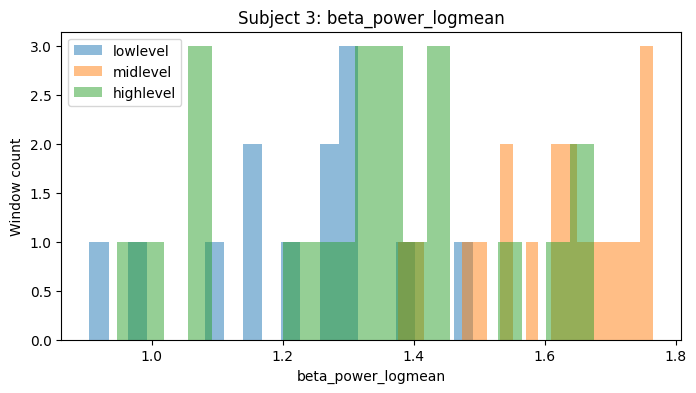

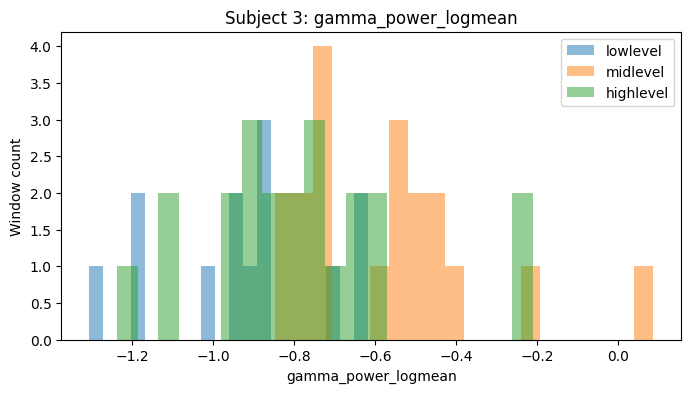

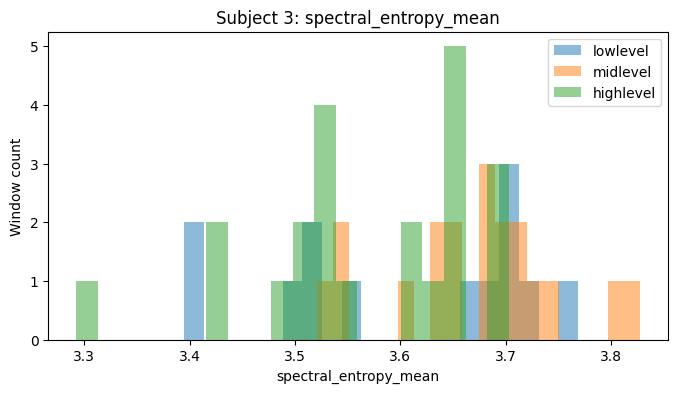

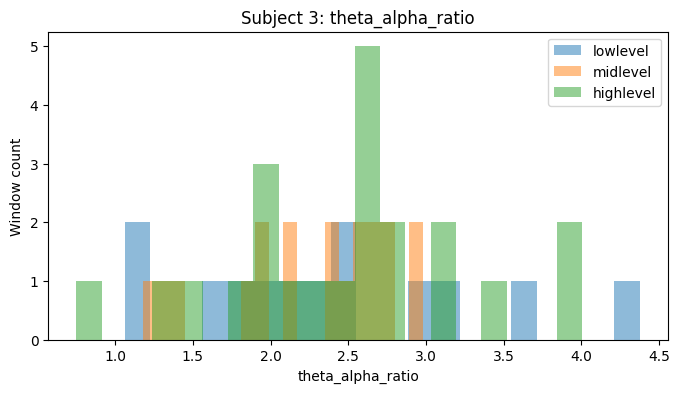

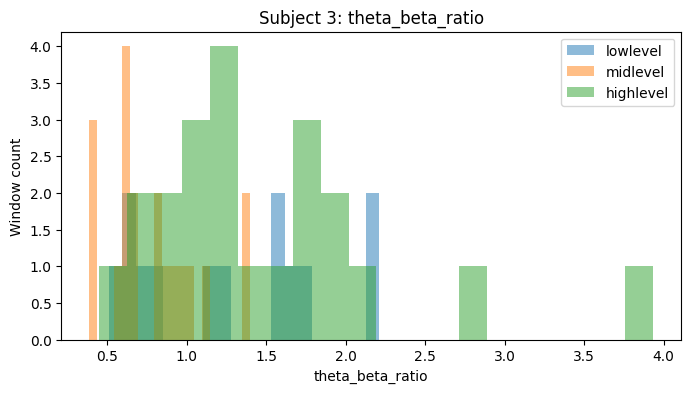

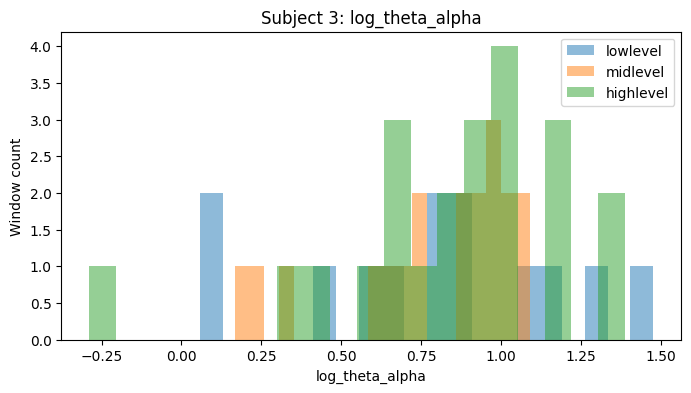

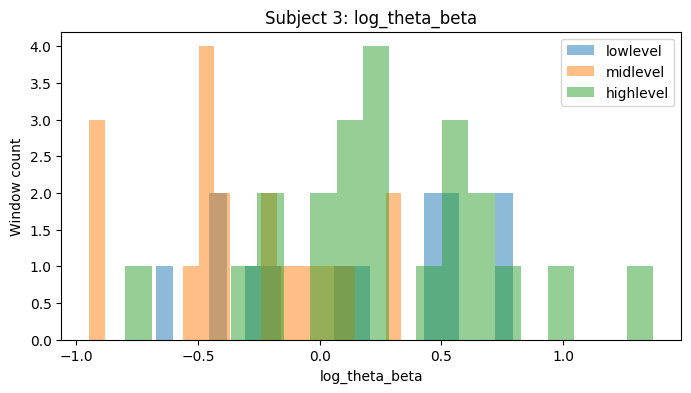

In [ ]:
feature_cols = [
    "mean_variance",
    "theta_power_logmean",
    "alpha_power_logmean",
    "beta_power_logmean",
    "gamma_power_logmean",
    "spectral_entropy_mean",
    "theta_alpha_ratio",
    "theta_beta_ratio",
    "log_theta_alpha",
    "log_theta_beta"
]

for s in SELECT_SUBJECTS:
    plot_subject_distributions(feat_df, s, feature_cols)

<Figure size 600x400 with 0 Axes>

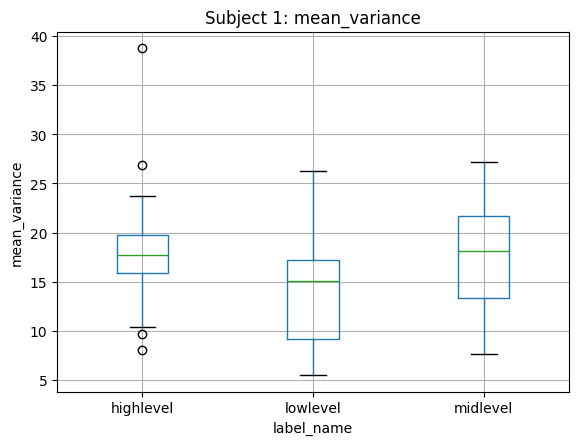

<Figure size 600x400 with 0 Axes>

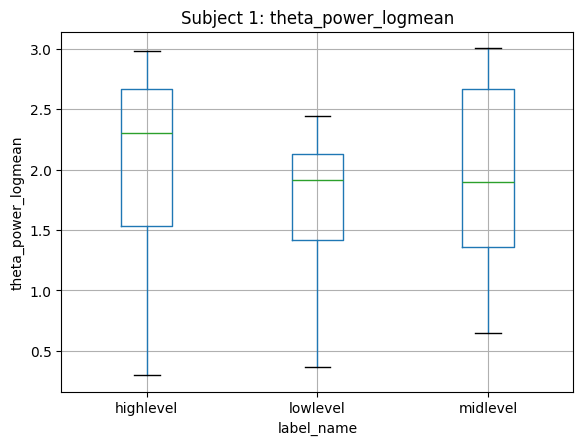

<Figure size 600x400 with 0 Axes>

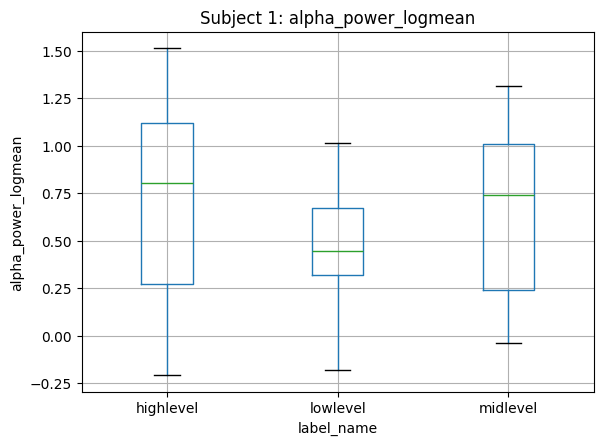

<Figure size 600x400 with 0 Axes>

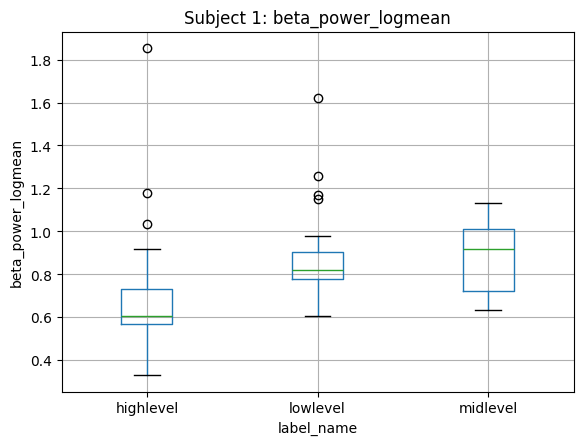

<Figure size 600x400 with 0 Axes>

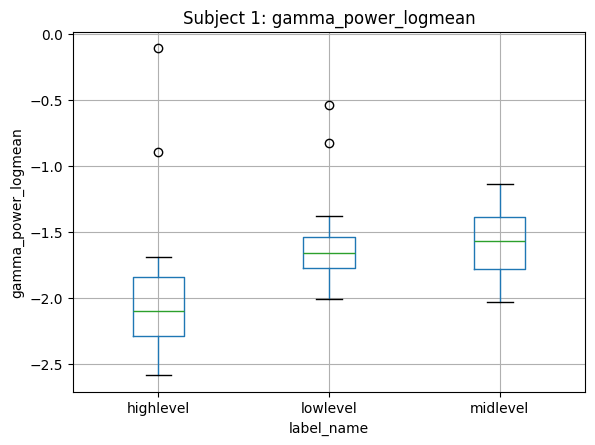

<Figure size 600x400 with 0 Axes>

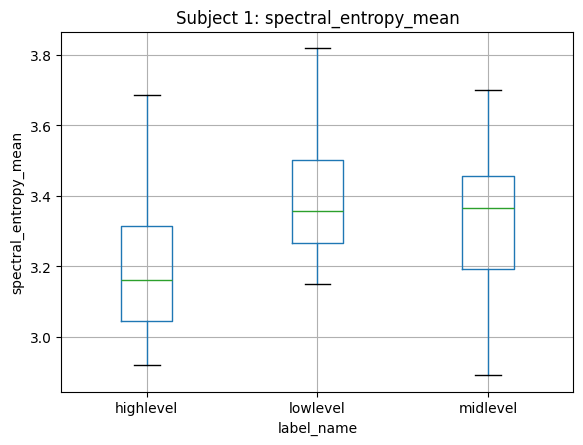

<Figure size 600x400 with 0 Axes>

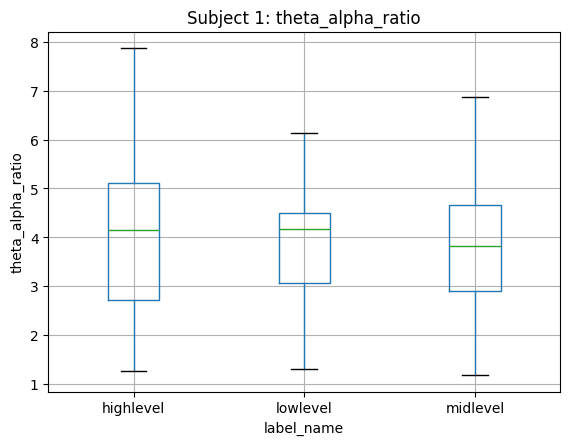

<Figure size 600x400 with 0 Axes>

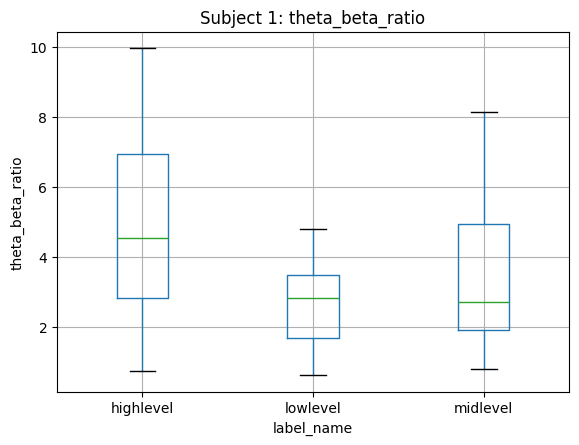

<Figure size 600x400 with 0 Axes>

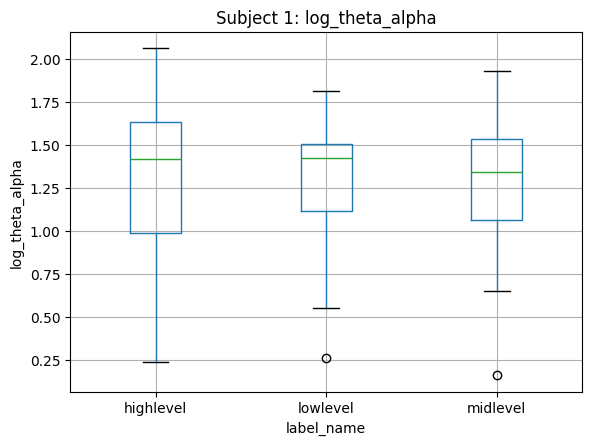

<Figure size 600x400 with 0 Axes>

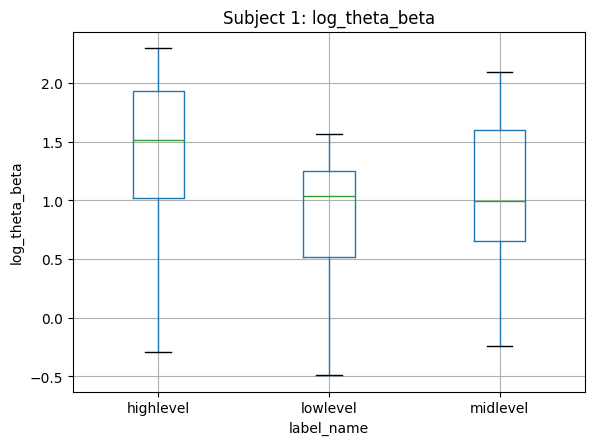

<Figure size 600x400 with 0 Axes>

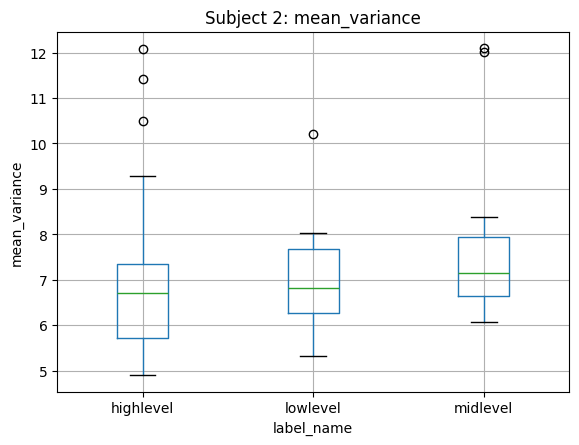

<Figure size 600x400 with 0 Axes>

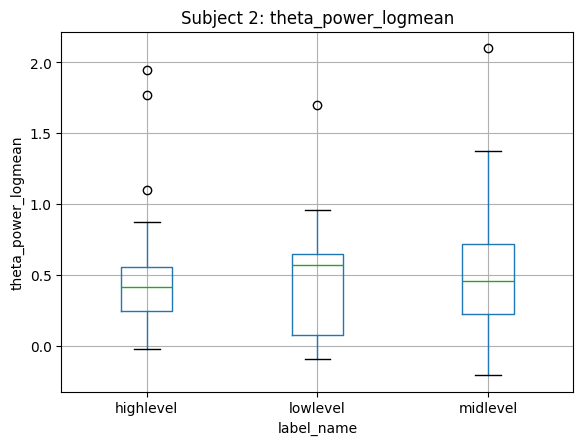

<Figure size 600x400 with 0 Axes>

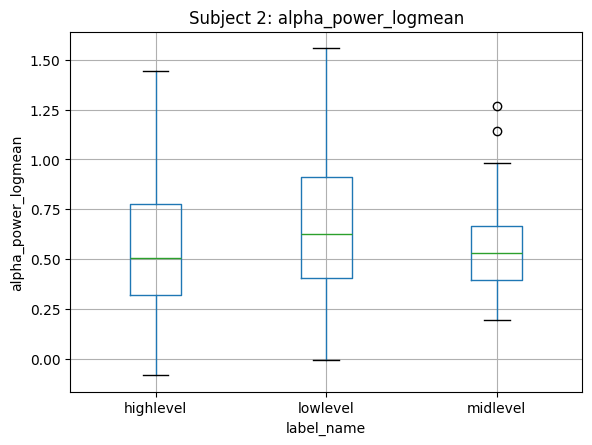

<Figure size 600x400 with 0 Axes>

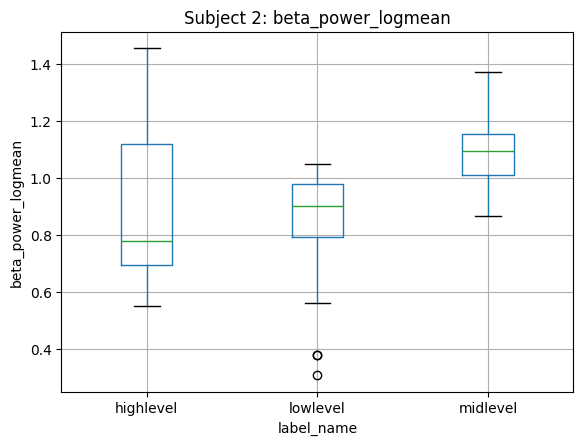

<Figure size 600x400 with 0 Axes>

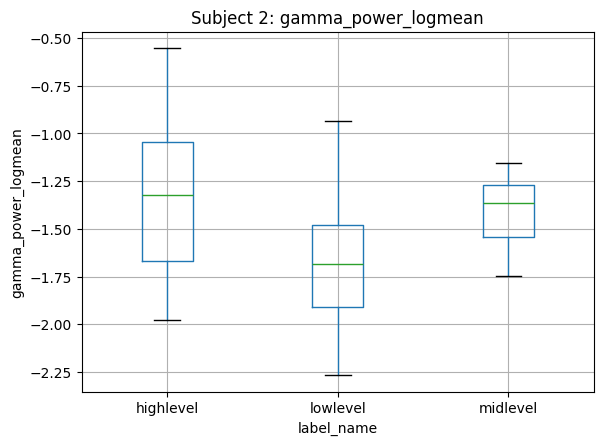

<Figure size 600x400 with 0 Axes>

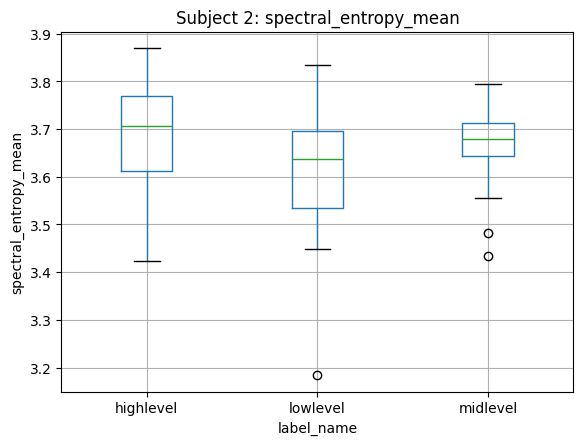

<Figure size 600x400 with 0 Axes>

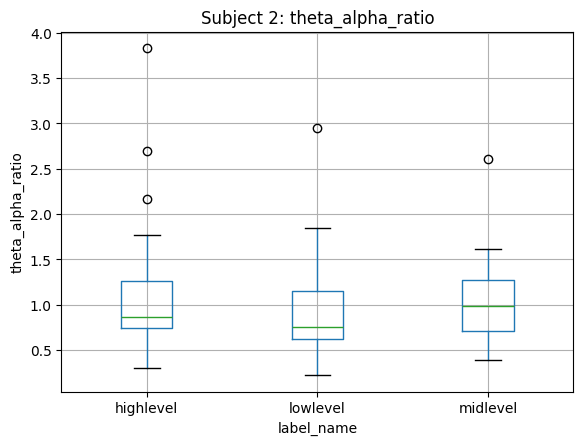

<Figure size 600x400 with 0 Axes>

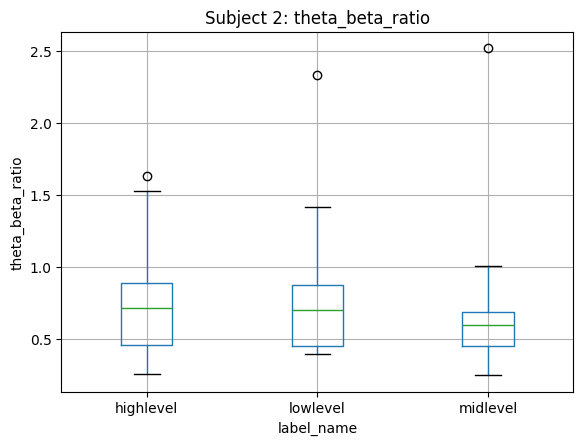

<Figure size 600x400 with 0 Axes>

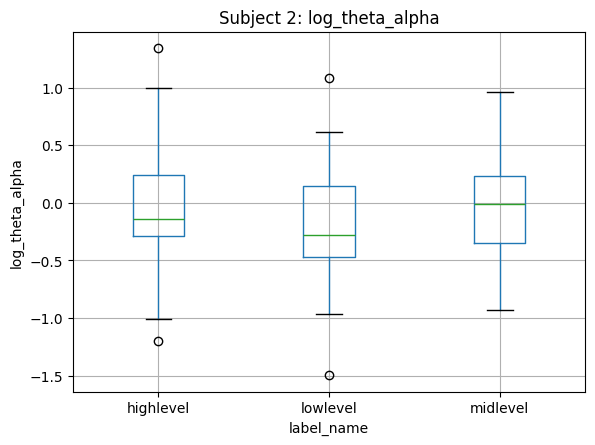

<Figure size 600x400 with 0 Axes>

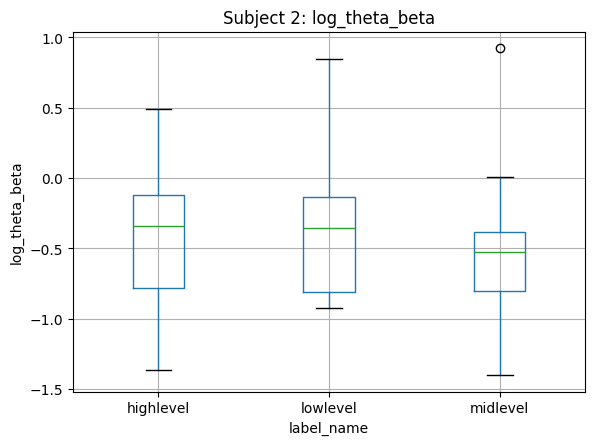

<Figure size 600x400 with 0 Axes>

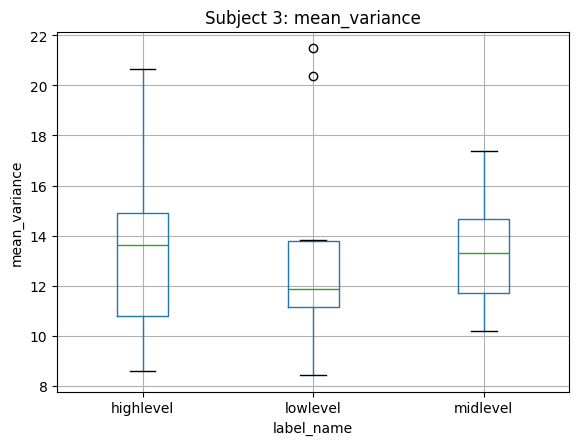

<Figure size 600x400 with 0 Axes>

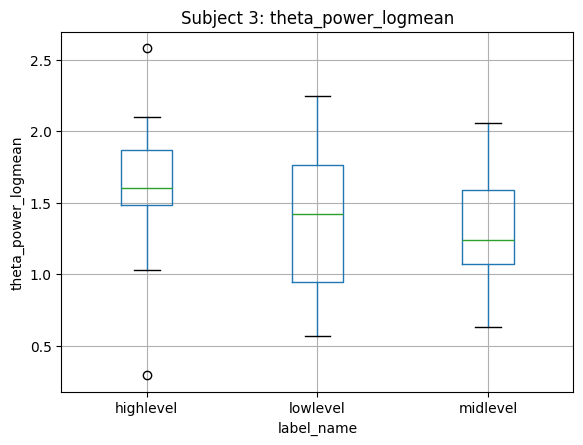

<Figure size 600x400 with 0 Axes>

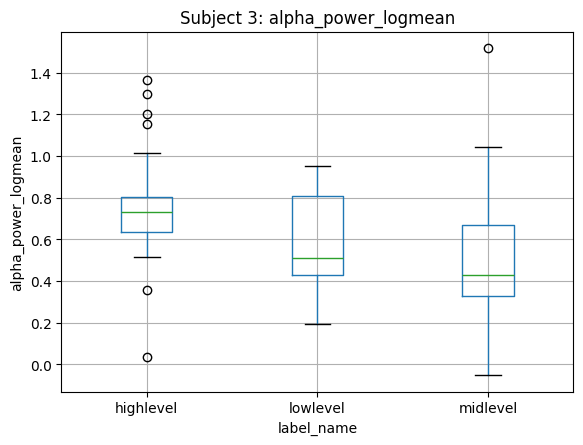

<Figure size 600x400 with 0 Axes>

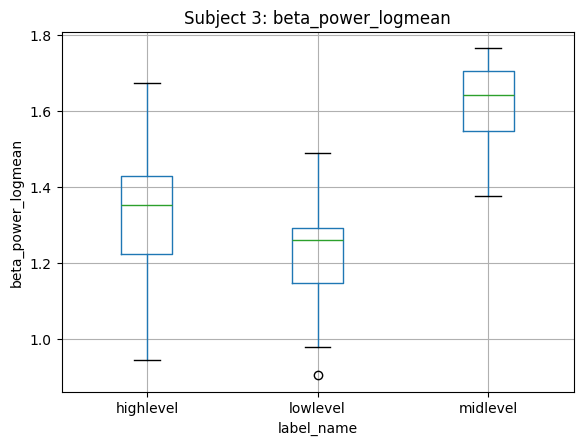

<Figure size 600x400 with 0 Axes>

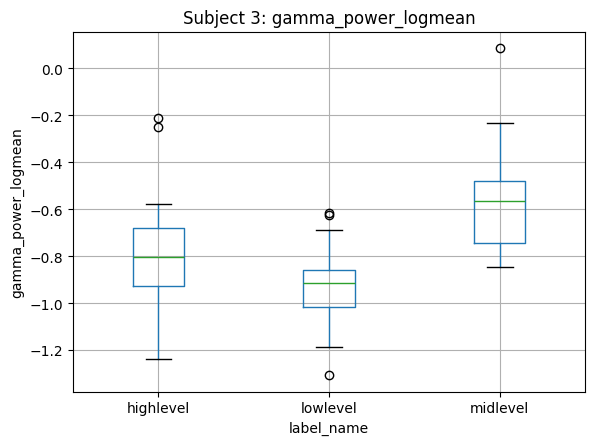

<Figure size 600x400 with 0 Axes>

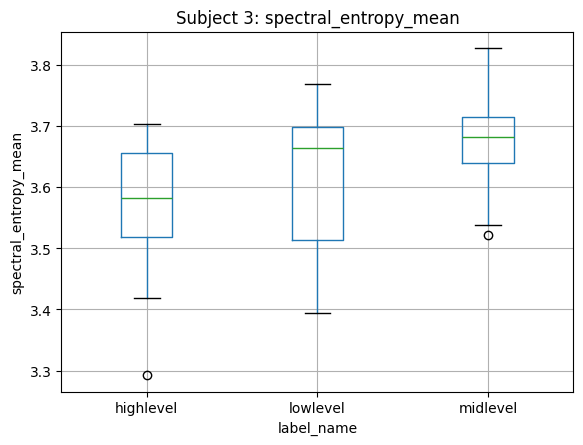

<Figure size 600x400 with 0 Axes>

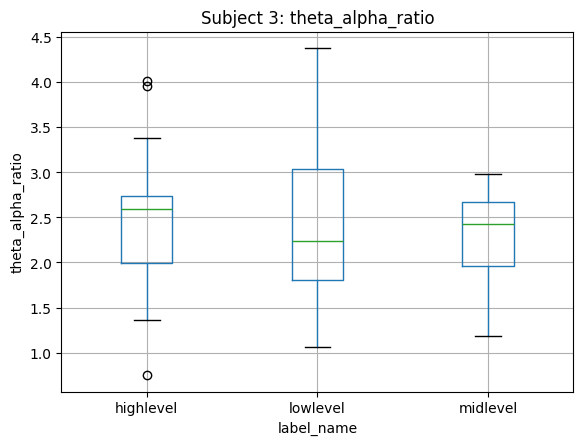

<Figure size 600x400 with 0 Axes>

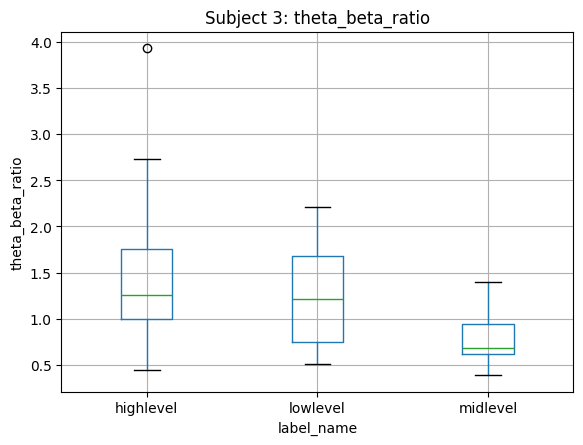

<Figure size 600x400 with 0 Axes>

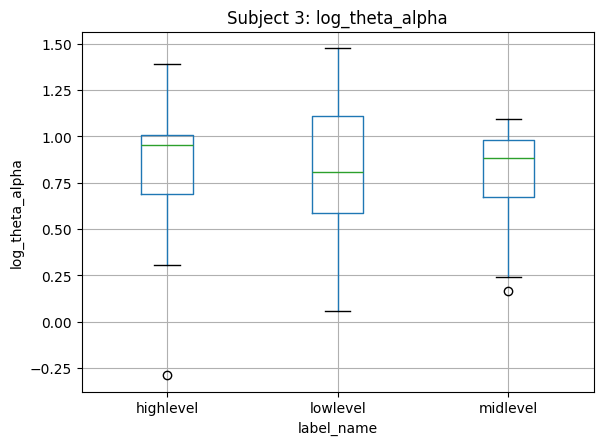

<Figure size 600x400 with 0 Axes>

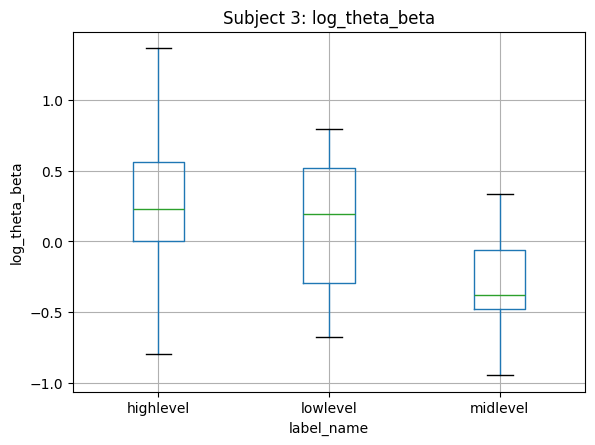

In [ ]:
def plot_subject_boxplots(df, subject_id, feature_cols):
    sub_df = df[df["subject"] == subject_id]

    for feat in feature_cols:
        plt.figure(figsize=(6,4))
        sub_df.boxplot(column=feat, by="label_name")
        plt.title(f"Subject {subject_id}: {feat}")
        plt.suptitle("")
        plt.ylabel(feat)
        plt.show()

for s in SELECT_SUBJECTS:
    plot_subject_boxplots(feat_df, s, feature_cols)

In [ ]:
feat_df_norm = feat_df.copy()

for feat in feature_cols:
    feat_df_norm[feat] = feat_df_norm.groupby("subject")[feat].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-8)
    )

<Figure size 600x400 with 0 Axes>

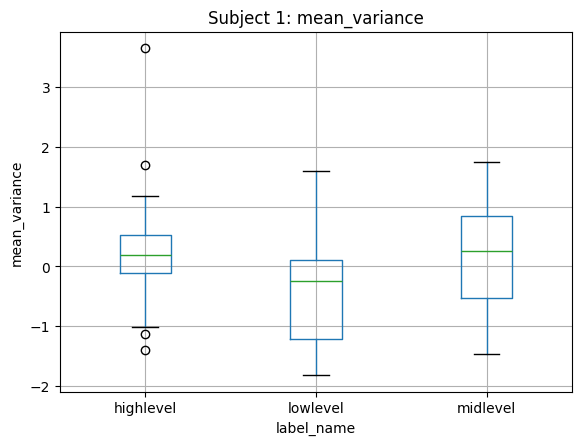

<Figure size 600x400 with 0 Axes>

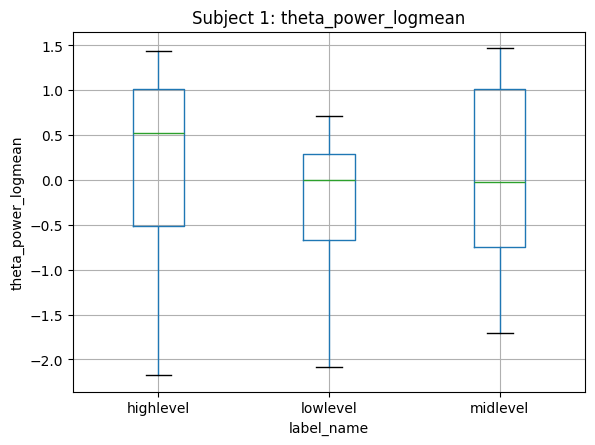

<Figure size 600x400 with 0 Axes>

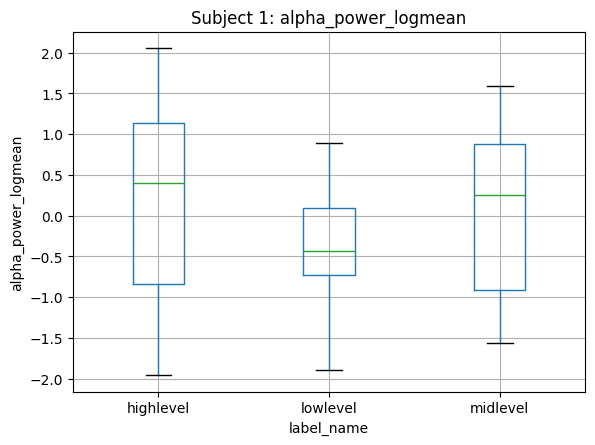

<Figure size 600x400 with 0 Axes>

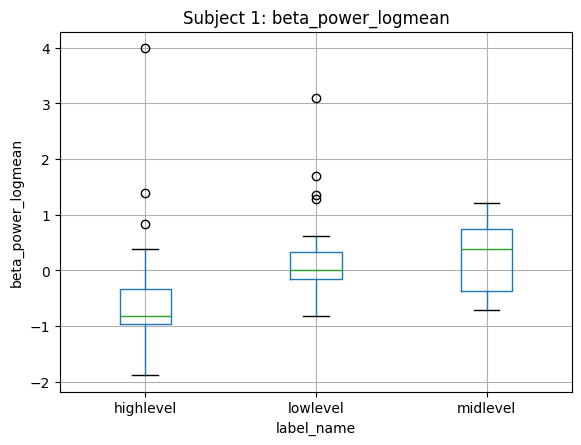

<Figure size 600x400 with 0 Axes>

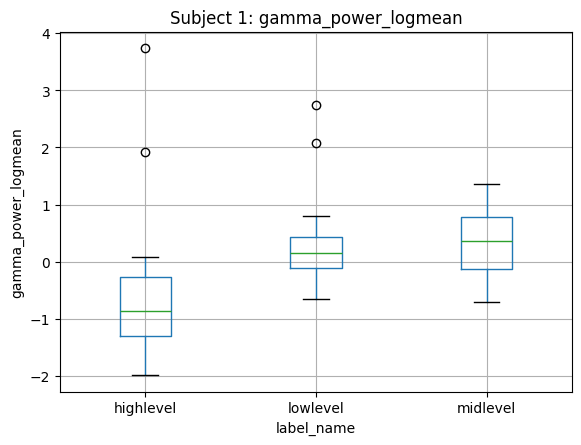

<Figure size 600x400 with 0 Axes>

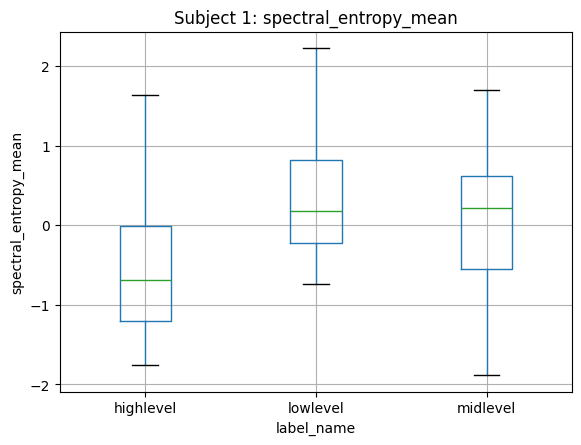

<Figure size 600x400 with 0 Axes>

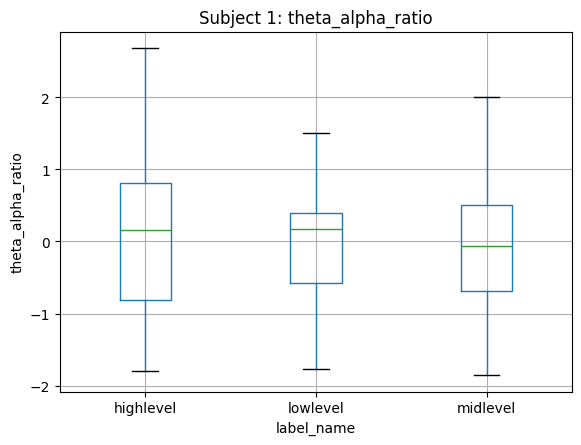

<Figure size 600x400 with 0 Axes>

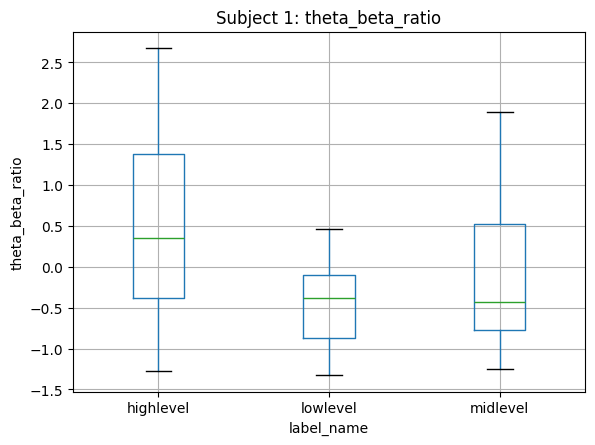

<Figure size 600x400 with 0 Axes>

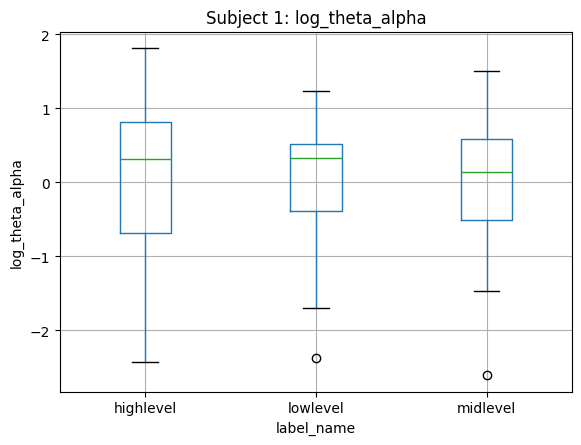

<Figure size 600x400 with 0 Axes>

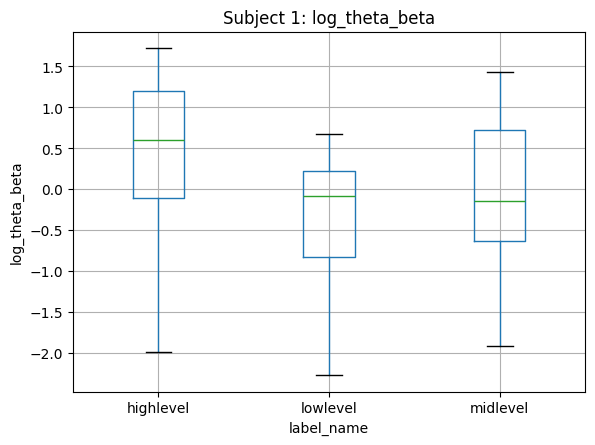

<Figure size 600x400 with 0 Axes>

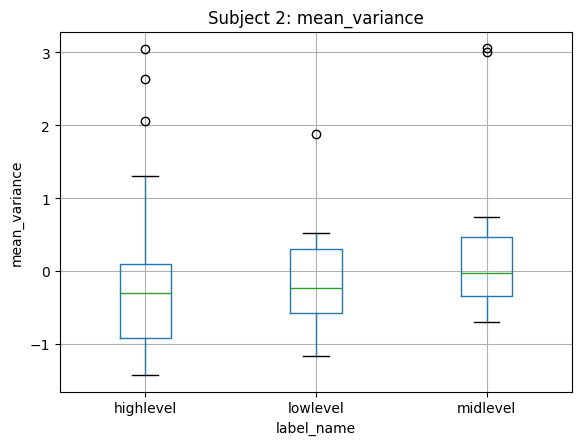

<Figure size 600x400 with 0 Axes>

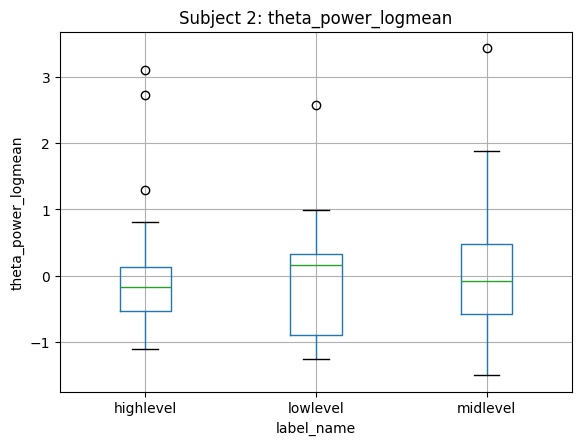

<Figure size 600x400 with 0 Axes>

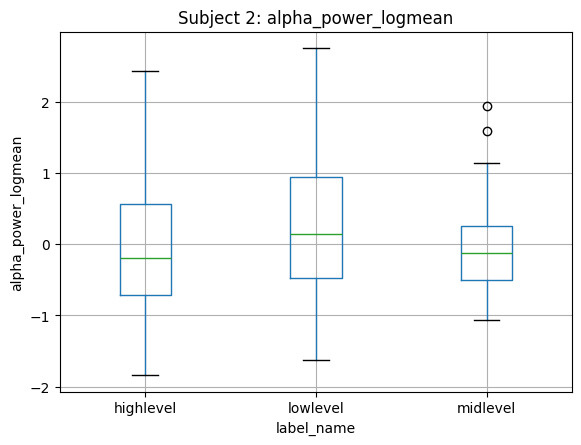

<Figure size 600x400 with 0 Axes>

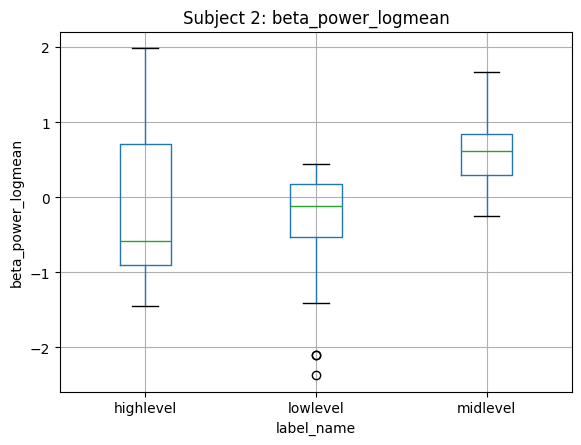

<Figure size 600x400 with 0 Axes>

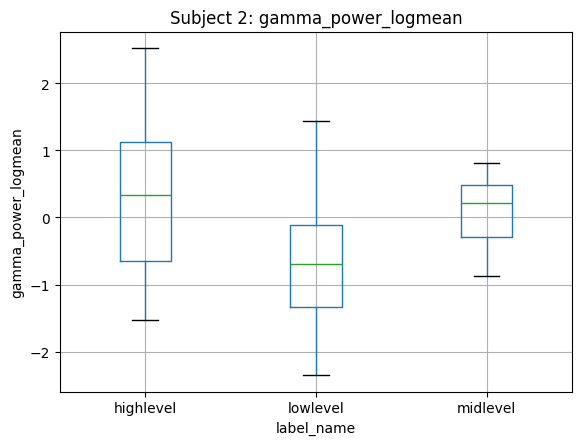

<Figure size 600x400 with 0 Axes>

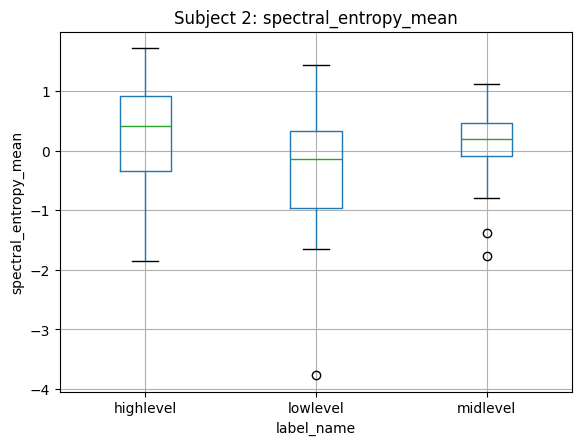

<Figure size 600x400 with 0 Axes>

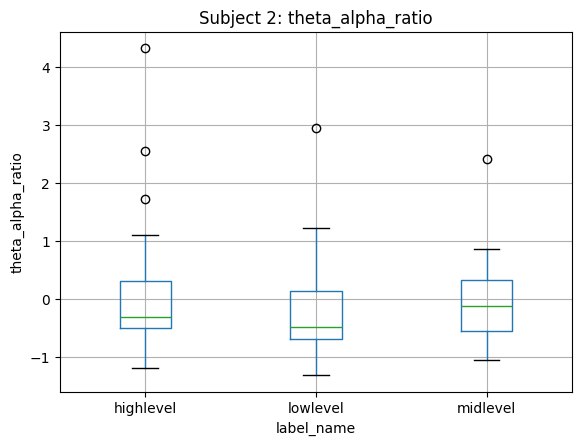

<Figure size 600x400 with 0 Axes>

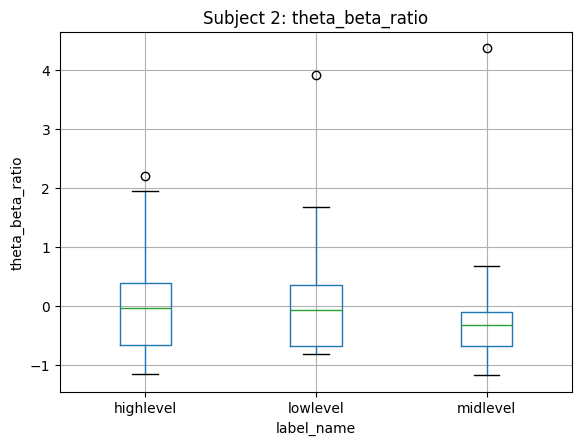

<Figure size 600x400 with 0 Axes>

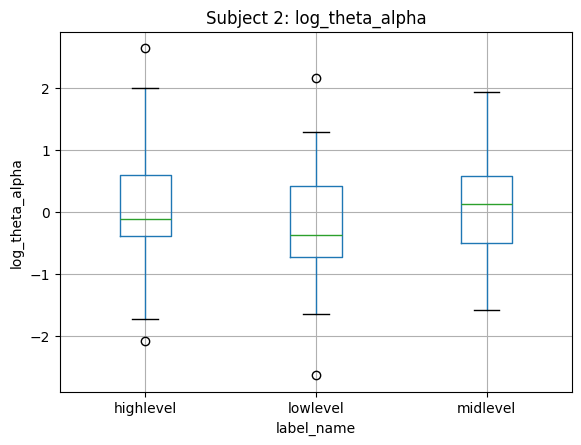

<Figure size 600x400 with 0 Axes>

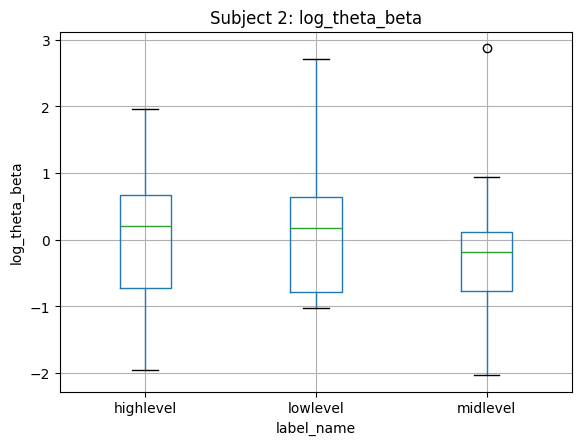

<Figure size 600x400 with 0 Axes>

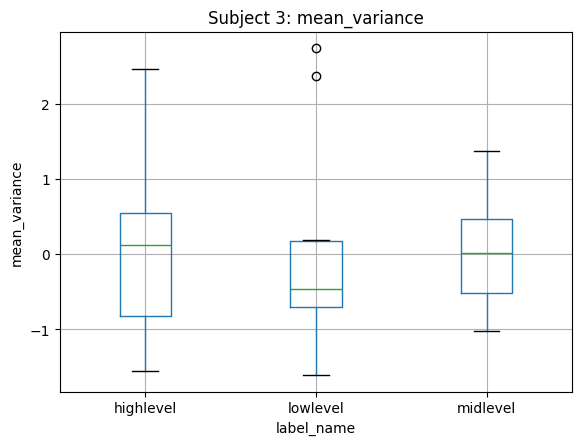

<Figure size 600x400 with 0 Axes>

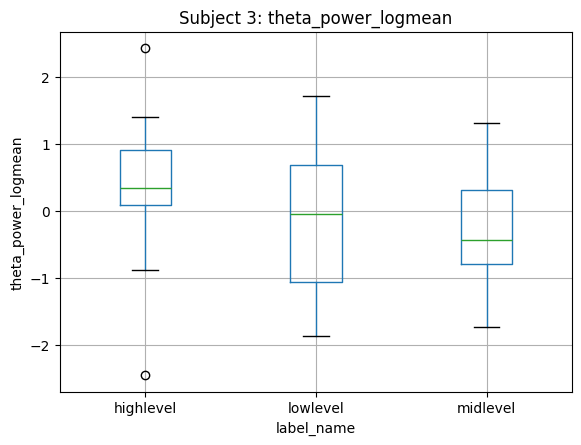

<Figure size 600x400 with 0 Axes>

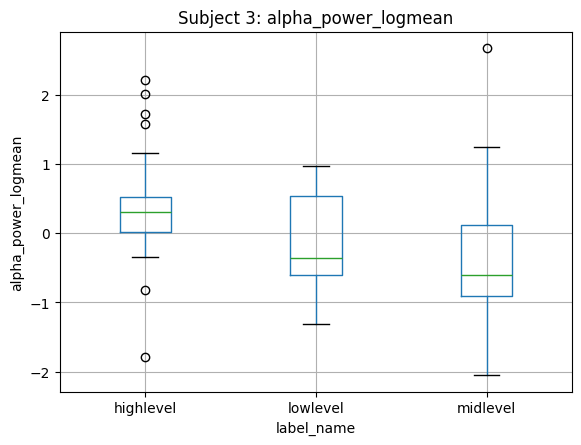

<Figure size 600x400 with 0 Axes>

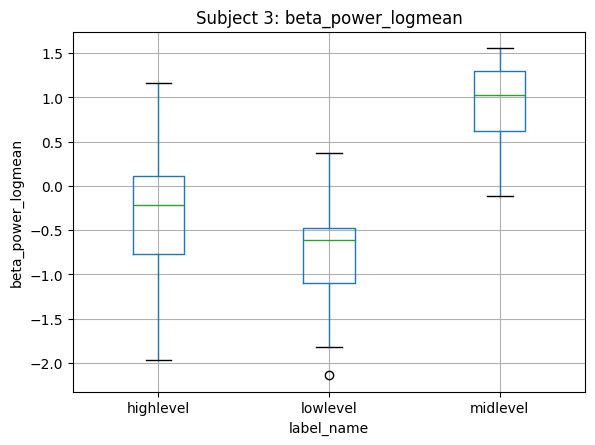

<Figure size 600x400 with 0 Axes>

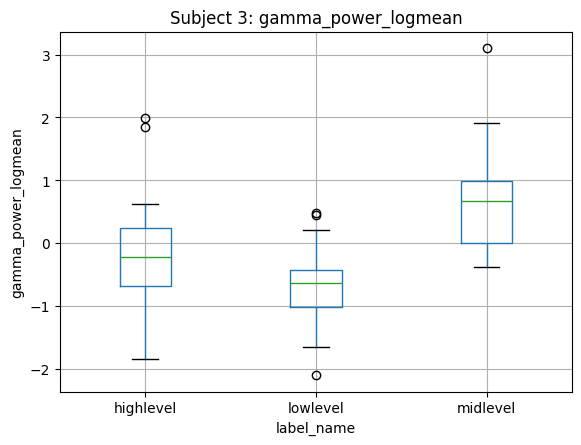

<Figure size 600x400 with 0 Axes>

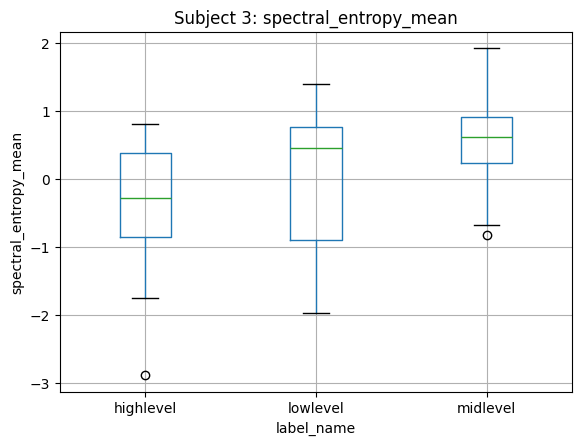

<Figure size 600x400 with 0 Axes>

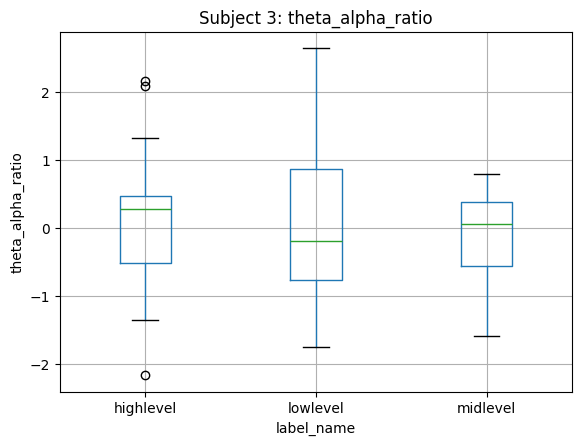

<Figure size 600x400 with 0 Axes>

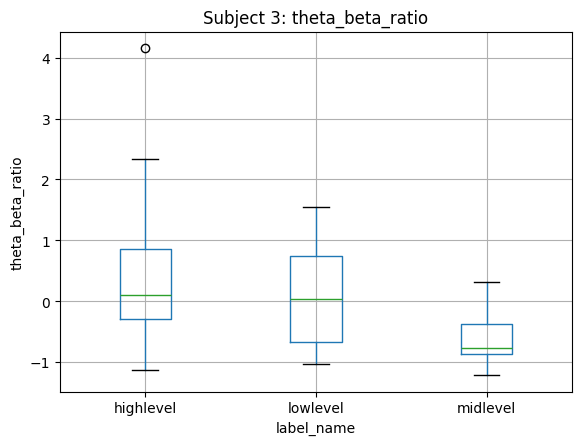

<Figure size 600x400 with 0 Axes>

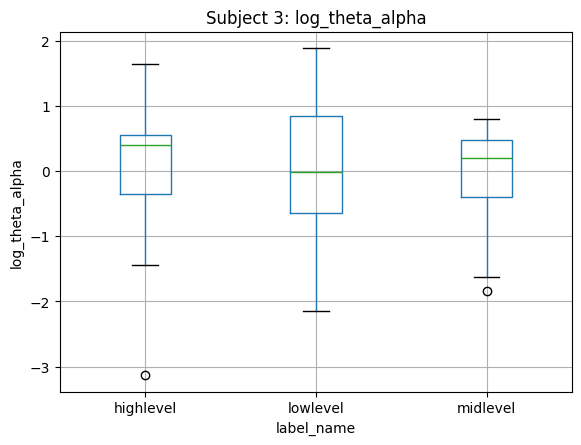

<Figure size 600x400 with 0 Axes>

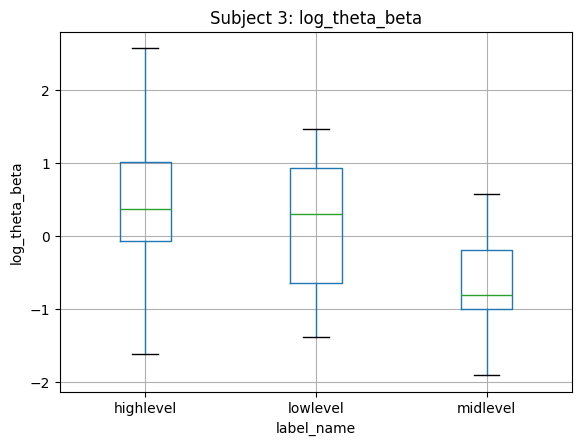

In [ ]:
for s in SELECT_SUBJECTS:
    plot_subject_boxplots(feat_df_norm, s, feature_cols)